[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lijingwang/UConn_MODFLOW_Lab/blob/main/UConn_Forest/06_Transient_MODFLOW.ipynb)

# Transient MODFLOW 6: UConn Fenton Forest — Monthly 2025
Author: Lijing Wang (lijing.wang@uconn.edu) for ERTH 4750 at University of Connecticut

This notebook extends **05_Steady_State_MODFLOW** to a **monthly transient simulation for 2025** (12 stress periods, Jan–Dec).

| Addition vs. notebook 05 | Source |
|---|---|
| Specific yield Sy (Layer 1) | SSURGO θ_s − θ_fc (spatially variable) |
| Specific yield Sy (Layer 2) | 0.20 (regolith / glacial till) |
| Monthly recharge via UZF | HBV daily P and T from `HBV_inputs_UConn_Forest/` |
| Snow/rain partition | Degree-day model (DDF = 2.74 mm/day/°C) |
| Adaptive time stepping | ATS sub-package of TDIS |
| Pumping well | `pumping_well.shp` |

**Before running:** Run **05_Steady_State_MODFLOW** and **03_Model_Input_Data_Prep** first.

In [ ]:
import os, sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = '/content/drive/MyDrive/MODFLOW_Lab/UConn_Forest'
    os.chdir(DRIVE_DIR)
    print('Working directory →', os.getcwd())
else:
    print('Local: working directory →', os.getcwd())

In [ ]:
! pip install flopy rasterio rioxarray geopandas sfrmaker dataretrieval baseflow -q

In [1]:
from pathlib import Path
import shutil, sys, os

data_dir   = Path('')
inputs_dir = Path('model_inputs')

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    mf6_exe = '/content/drive/MyDrive/mf6'
    import subprocess; subprocess.run(['chmod', '755', mf6_exe], check=False)
else:
    mf6_exe = shutil.which('mf6') or str(Path.home() / 'bin' / 'mf6')

print(f'mf6 executable : {mf6_exe}')
print(f'Data directory : {data_dir.resolve()}')

mf6 executable : /Users/lijing.wang/bin/mf6
Data directory : /Users/lijing.wang/Desktop/MODFLOW_Lab/Real_case_study


In [2]:
import flopy
import flopy.utils.binaryfile as bf
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from collections import Counter
import requests, io
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import rasterize as rio_rasterize
from rasterio.enums import Resampling
import rioxarray as rxr
from pyproj import Transformer
from flopy.plot import PlotMapView, PlotCrossSection
from flopy.discretization import StructuredGrid
import warnings
warnings.simplefilter('ignore', DeprecationWarning)
%matplotlib inline
%config InlineBackend.figure_format='retina'

## 1. Load DEM and Spatial Parameters

Identical to notebook 05 — same grid, same K, same layer geometry.

In [3]:
dem_path = str(inputs_dir / 'dem_10m.tif')

with rasterio.open(dem_path) as src:
    dem           = src.read(1).astype(float)
    dem_crs       = src.crs
    dem_transform = src.transform
    dem_bounds    = src.bounds
    dx            = src.res[0]   # actual pixel width  (~10 m)
    dy            = src.res[1]   # actual pixel height (~10 m)

dem[dem < 0] = np.nan
inactive_mask = np.isnan(dem)
active        = ~inactive_mask
nrow, ncol    = dem.shape
xmin, ymin, xmax, ymax = dem_bounds

print(f'DEM shape: {dem.shape}  |  CRS: {dem_crs}')
print(f'Resolution: {dx:.2f} m × {dy:.2f} m')

DEM shape: (324, 311)  |  CRS: EPSG:32618
Resolution: 8.72 m × 8.72 m


In [4]:
dem_ref = rxr.open_rasterio(dem_path, masked=True).squeeze()

def resample_to_10m(tif_path, method=Resampling.average):
    src = rxr.open_rasterio(str(tif_path), masked=True).squeeze()
    dst = src.rio.reproject_match(dem_ref, resampling=method)
    arr = np.array(dst, dtype=float)
    arr[~np.isfinite(arr)] = np.nan
    return arr

K_lay1_raw  = resample_to_10m(inputs_dir / 'soil_ksat.tif')
Sy_lay1_raw = resample_to_10m(inputs_dir / 'soil_Sy.tif')
d_soil_raw  = resample_to_10m(inputs_dir / 'soil_depth_m.tif')
d_rock_raw  = resample_to_10m(inputs_dir / 'depth_to_bedrock_m.tif',
                               method=Resampling.bilinear)
thts_raw    = resample_to_10m(inputs_dir / 'soil_porosity.tif')

K_lay1  = np.where(np.isfinite(K_lay1_raw)  & (K_lay1_raw  > 0),    K_lay1_raw,  np.nanmedian(K_lay1_raw))
Sy_lay1 = np.where(np.isfinite(Sy_lay1_raw) & (Sy_lay1_raw > 0),    Sy_lay1_raw, np.nanmedian(Sy_lay1_raw))
d_soil  = np.where(np.isfinite(d_soil_raw)  & (d_soil_raw  > 0.05), d_soil_raw,  np.nanmedian(d_soil_raw))
d_rock  = np.where(np.isfinite(d_rock_raw)  & (d_rock_raw  > 0.5),  d_rock_raw,  np.nanmedian(d_rock_raw))
d_soil  = np.minimum(d_soil, d_rock * 0.8)
d_soil  = np.maximum(d_soil, 0.2)

# UZF soil moisture parameters
thts_arr = np.where(np.isfinite(thts_raw) & (thts_raw > 0), thts_raw, np.nanmedian(thts_raw))
thts_arr[inactive_mask] = np.nanmedian(thts_arr)

thtr_arr = np.full_like(thts_arr, 0.05)   # residual water content

# Field capacity ≈ θ_s − Sy (water held against gravity after drainage)
thfc_arr = np.maximum(thts_arr - Sy_lay1, 0.05)
thfc_arr[inactive_mask] = np.nanmedian(thfc_arr)

# Initial UZF water content = field capacity (pre-wetted soil, realistic starting state).
thti_arr = thts_arr.copy()

# Layer 2: regolith (GLHYMPS)
glhymps = gpd.read_file(str(inputs_dir / 'regolith_glhymps.shp')).to_crs(dem_crs)
if 'K_m_s' not in glhymps.columns:
    glhymps['K_m_s'] = 10 ** (glhymps['logK_Ferr_'] / 100.0) * 9.81e6
tf     = from_bounds(*dem_bounds, width=ncol, height=nrow)
K_vals = pd.to_numeric(glhymps['K_m_s'], errors='coerce').fillna(1e-5).clip(lower=1e-9).values
K_lay2 = rio_rasterize([(g, float(v)) for g, v in zip(glhymps.geometry, K_vals)],
                        out_shape=(nrow, ncol), transform=tf,
                        fill=1e-10, dtype='float64')

print(f'K_lay1  : {K_lay1[active].mean():.2e} m/s  (SSURGO)')
print(f'K_lay2  : {K_lay2[active].mean():.2e} m/s  (GLHYMPS)')
print(f'θ_s     : {thts_arr[active].mean():.3f}  (porosity)')
print(f'θ_fc    : {thfc_arr[active].mean():.3f}  (field capacity = θ_s − Sy)')
print(f'θ_init  : {thti_arr[active].mean():.3f}  (= θ_fc, pre-wetted starting state)')

K_lay1  : 6.49e-05 m/s  (SSURGO)
K_lay2  : 2.95e-04 m/s  (GLHYMPS)
θ_s     : 0.457  (porosity)
θ_fc    : 0.341  (field capacity = θ_s − Sy)
θ_init  : 0.457  (= θ_fc, pre-wetted starting state)


## 2. Build the Structured Grid

In [5]:
nlay = 2
delc = np.full((nrow,), dy)
delr = np.full((ncol,), dx)

top  = np.where(inactive_mask, 500.0, dem)
botm = np.zeros((nlay, nrow, ncol))
botm[0] = top - d_soil
botm[1] = top - d_rock
botm[1] = np.minimum(botm[1], botm[0] - 1.0)

idomain = np.ones((nlay, nrow, ncol), dtype=int)
for k in range(nlay):
    idomain[k, inactive_mask] = 0

print(f'Grid  : {nlay} layers × {nrow} rows × {ncol} cols')
print(f'Active cells: {(idomain[0]==1).sum():,}')

sgrid = StructuredGrid(
    delc=delc, delr=delr, top=top, botm=botm,
    idomain=idomain, xoff=xmin, yoff=ymin)
sgrid.set_coord_info(crs=dem_crs)


Grid  : 2 layers × 324 rows × 311 cols
Active cells: 44,003


## 3. Monthly Climate Data — 2025

**Data sources (`HBV_inputs_UConn_Forest/`):**
- `inputPrecipTemp.csv` — daily P (mm/day) and T (°C)
- `inputMonthlyTempEvap.csv` — monthly PE climatology: `T_avg_month`, `PEm_day`

### Snow / Rain Partition — Degree-Day Model

Precipitation is partitioned daily using a temperature threshold `T_snow`:

| T < T_snow | T ≥ T_snow |
|---|---|
| Snow → adds to SWE | Rain → immediate liquid input |

Snowmelt (mm/day) = DDF × max(T − T_melt, 0),  capped at available SWE.

The **liquid input** (rain + melt) is what enters the soil surface and becomes `finf` in UZF.
This delays the recharge pulse from winter snowpack to spring melt, which is important for
capturing seasonal groundwater response in New England.

**HBV temperature-corrected daily PE:**
$$\text{PE}_{day} = \bigl(1 + c_{par} \cdot (T_{day} - \bar{T}_{month})\bigr) \times \overline{PE}_{month}, \quad c_{par} = 0.1$$

Monthly water balance 2025  (DDF=2.74 mm/day/°C,  T_snow=0.0°C):
  Mo      P   Rain   Snow   Melt  Liquid     PE    L-PE
 Jan     44     35      9      1      36     17      19
 Feb     85     17     68     53      70     29      41
 Mar     98     98      0     23     121     82      39
 Apr     99     99      0      0      99    105      -7
 May    224    224      0      0     224    147      77
 Jun     63     63      0      0      63    203    -140
 Jul    123    123      0      0     123    206     -83
 Aug    102    102      0      0     102    137     -34
 Sep    109    109      0      0     109    110      -1
 Oct    139    139      0      0     139     49      90
 Nov     64     64      0      0      64     29      35
 Dec    111     67     44     30      97     13      84
 TOT   1260   1140    121    107    1247   1127


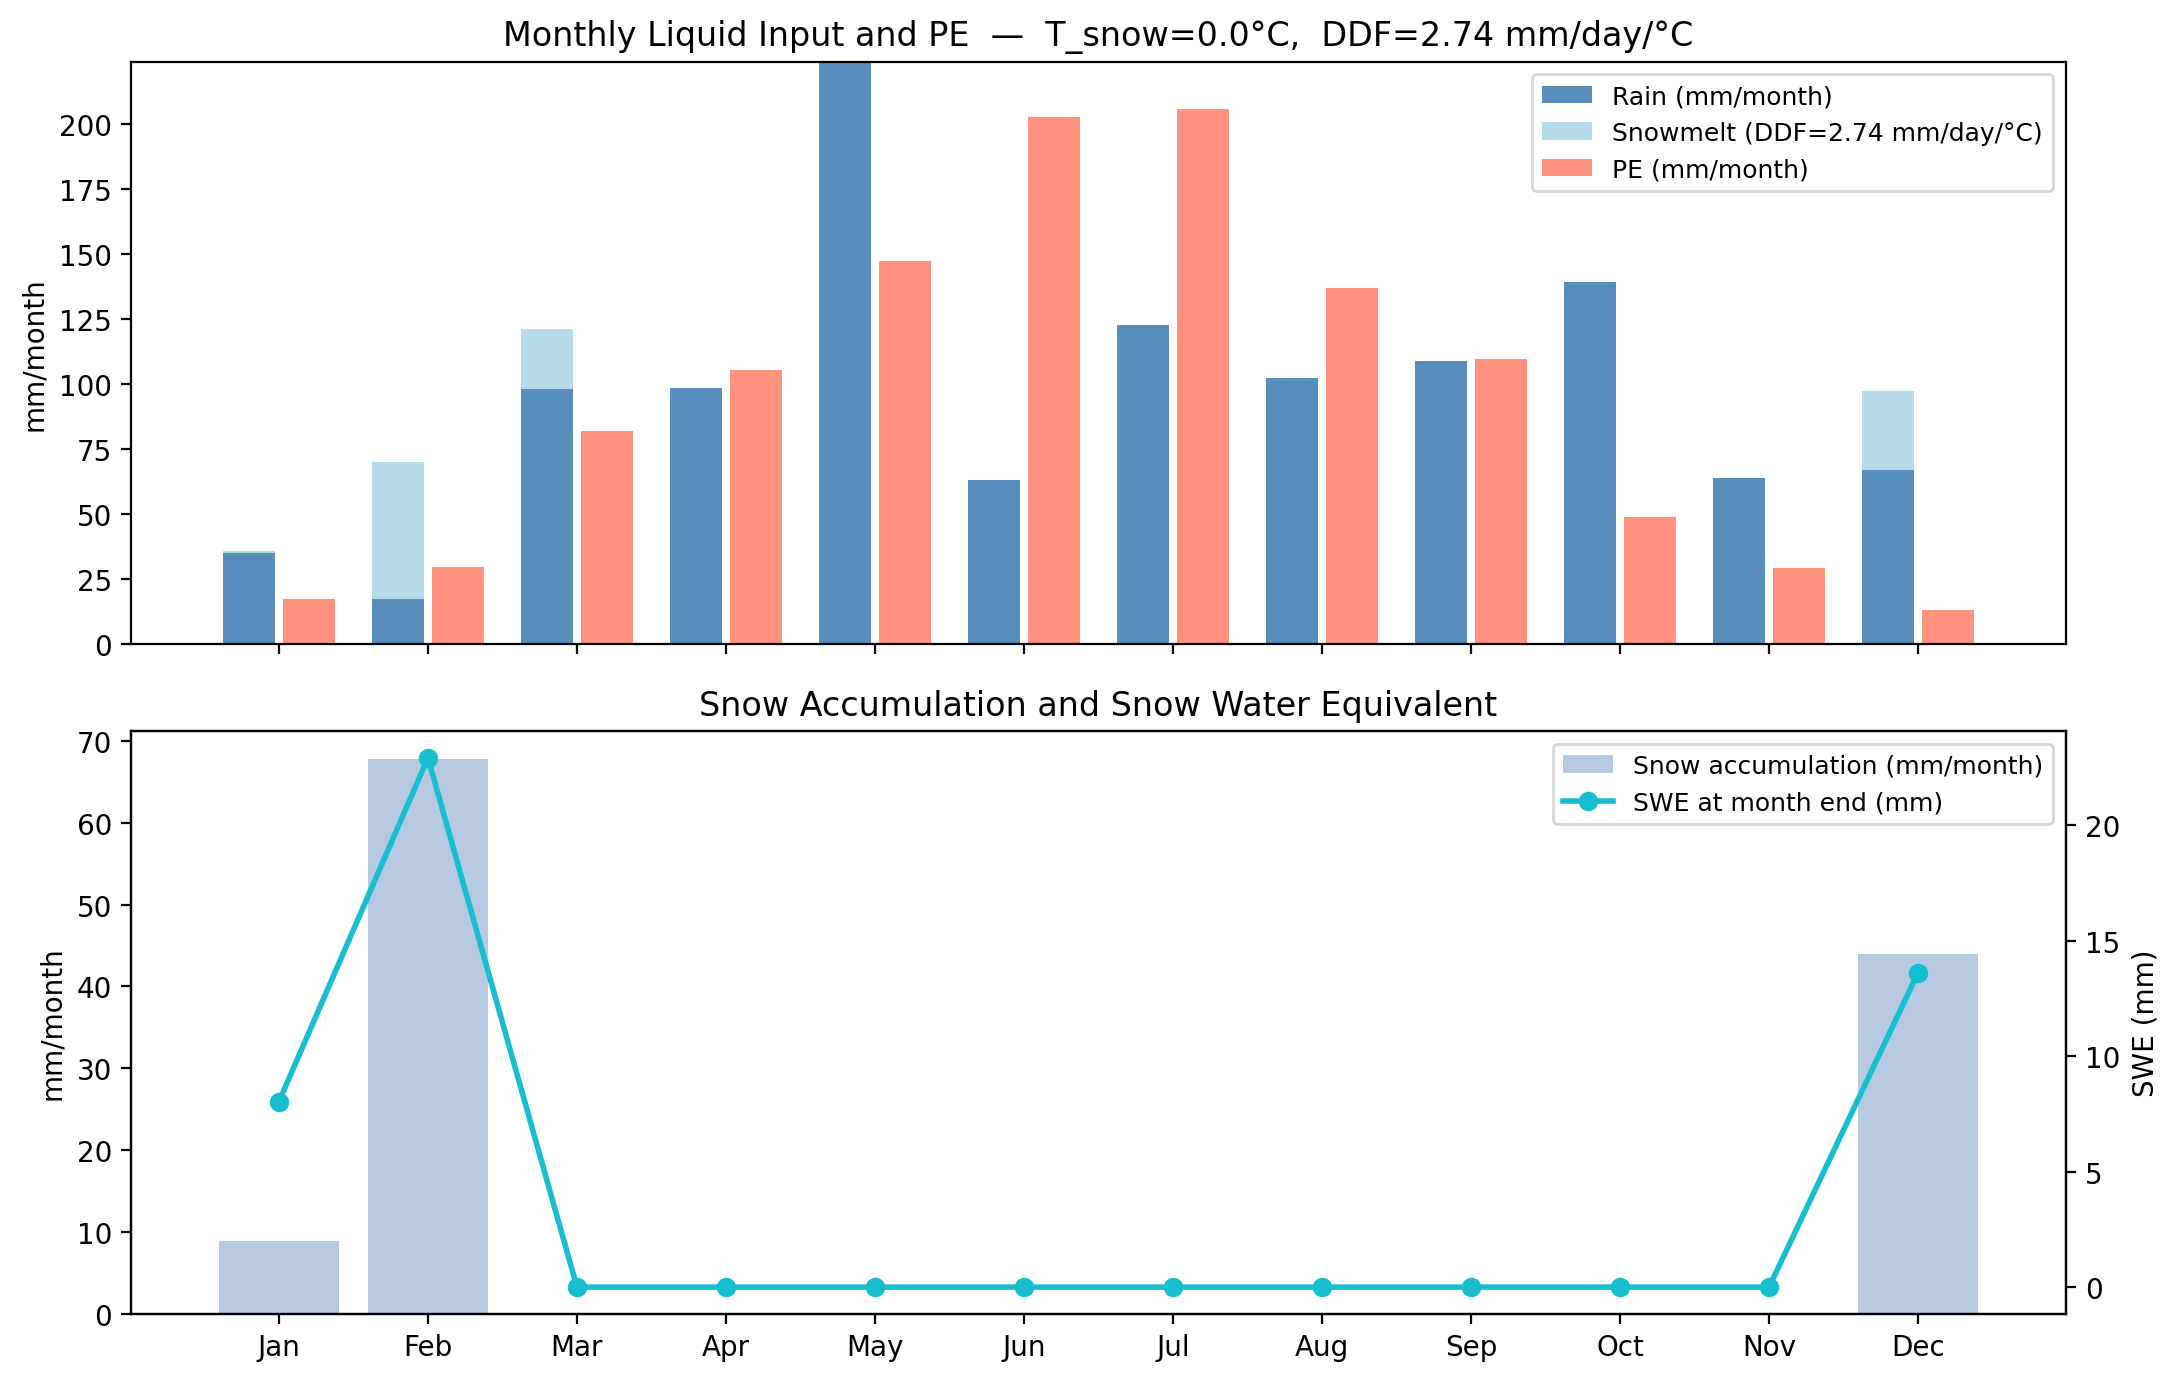

In [6]:
import calendar

hbv_dir = Path('HBV_inputs_UConn_Forest')

# ── Monthly calendar ──────────────────────────────────────────────
months        = range(1, 13)
month_labels  = [pd.Timestamp(f'2025-{m:02d}-01') for m in months]
days_in_month = [calendar.monthrange(2025, m)[1] for m in months]

# ── Daily P and T for 2025 ────────────────────────────────────────
pt = pd.read_csv(hbv_dir / 'inputPrecipTemp.csv',
                 parse_dates=['Time'], dayfirst=False)
pt = pt[pt['Time'].dt.year == 2025].copy().set_index('Time').sort_index()
assert len(pt) == 365, f'Expected 365 days, got {len(pt)}'

dates_2025 = pt.index
prcp_day   = pt['Precipitation'].values   # mm/day
temp_day   = pt['Temperature'].values     # °C

# ── Monthly PE climatology lookup ─────────────────────────────────
pe_lu = pd.read_csv(hbv_dir / 'inputMonthlyTempEvap.csv', index_col='month')

# ── HBV temperature-corrected daily PE ───────────────────────────
cpar   = 0.1
pe_day = np.array([
    (1.0 + cpar * (temp_day[i] - pe_lu.loc[m, 'T_avg_month'])) * pe_lu.loc[m, 'PEm_day']
    for i, m in enumerate(dates_2025.month)
])
pe_day = np.maximum(pe_day, 0.0)

# ── Degree-day snow model ─────────────────────────────────────────
T_snow = 0.0    # °C — snow/rain threshold
T_melt = 0.0    # °C — melt begins above this temperature
DDF    = 2.74   # mm/day/°C — degree-day factor

swe        = 0.0
rain_day   = np.zeros(len(prcp_day))
melt_day   = np.zeros(len(prcp_day))
swe_daily  = np.zeros(len(prcp_day))

for i in range(len(prcp_day)):
    if temp_day[i] < T_snow:
        rain_day[i] = 0.0
        swe += prcp_day[i]                              # accumulate as snow
    else:
        rain_day[i] = prcp_day[i]                       # falls as rain
    melt_i      = min(swe, DDF * max(temp_day[i] - T_melt, 0.0))
    swe        -= melt_i
    melt_day[i] = melt_i
    swe_daily[i] = swe

liquid_day = rain_day + melt_day   # total liquid reaching soil surface

# ── Monthly aggregation ───────────────────────────────────────────
def monthly_sum(arr):
    return np.array([arr[dates_2025.month == m].sum() for m in months])

prcp_monthly   = monthly_sum(prcp_day)
rain_monthly   = monthly_sum(rain_day)
snow_monthly   = monthly_sum(prcp_day - rain_day)
melt_monthly   = monthly_sum(melt_day)
liquid_monthly = monthly_sum(liquid_day)
pe_monthly     = monthly_sum(pe_day)

swe_end_month = np.array([
    swe_daily[np.where(dates_2025.month == m)[0][-1]] for m in months
])

# ── Monthly rates for UZF [m/s] ───────────────────────────────────
secs_per_month = np.array(days_in_month) * 86400.0
finf_m_s = liquid_monthly / (secs_per_month * 1000.0)   # liquid input → infiltration
pet_m_s  = pe_monthly     / (secs_per_month * 1000.0)

# ── Summary table ─────────────────────────────────────────────────
xlabels = [calendar.month_abbr[m] for m in months]
print(f'Monthly water balance 2025  (DDF={DDF} mm/day/°C,  T_snow={T_snow}°C):')
print(f'{"Mo":>4}  {"P":>5}  {"Rain":>5}  {"Snow":>5}  {"Melt":>5}  {"Liquid":>6}  {"PE":>5}  {"L-PE":>6}')
for i, m in enumerate(months):
    print(f'{calendar.month_abbr[m]:>4}  {prcp_monthly[i]:5.0f}  {rain_monthly[i]:5.0f}  '
          f'{snow_monthly[i]:5.0f}  {melt_monthly[i]:5.0f}  {liquid_monthly[i]:6.0f}  '
          f'{pe_monthly[i]:5.0f}  {liquid_monthly[i]-pe_monthly[i]:6.0f}')
print(f'{"TOT":>4}  {prcp_monthly.sum():5.0f}  {rain_monthly.sum():5.0f}  '
      f'{snow_monthly.sum():5.0f}  {melt_monthly.sum():5.0f}  {liquid_monthly.sum():6.0f}  '
      f'{pe_monthly.sum():5.0f}')

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
bar_x = np.arange(12)

# Panel 1 — liquid input partition and PE
axes[0].bar(bar_x - 0.2, rain_monthly,  0.35, color='steelblue', alpha=0.9, label='Rain (mm/month)')
axes[0].bar(bar_x - 0.2, melt_monthly,  0.35, color='lightblue', alpha=0.9,
            bottom=rain_monthly, label=f'Snowmelt (DDF={DDF} mm/day/°C)')
axes[0].bar(bar_x + 0.2, pe_monthly,    0.35, color='tomato',    alpha=0.7, label='PE (mm/month)')
axes[0].set_ylabel('mm/month')
axes[0].set_title(f'Monthly Liquid Input and PE  —  T_snow={T_snow}°C,  DDF={DDF} mm/day/°C')
axes[0].legend(fontsize=9)

# Panel 2 — SWE and snow accumulation
ax2b = axes[1].twinx()
axes[1].bar(bar_x, snow_monthly, color='lightsteelblue', alpha=0.9,
            label='Snow accumulation (mm/month)')
ax2b.plot(bar_x, swe_end_month, 'C9-o', lw=2, ms=6, label='SWE at month end (mm)')
axes[1].set_ylabel('mm/month')
ax2b.set_ylabel('SWE (mm)')
axes[1].set_title('Snow Accumulation and Snow Water Equivalent')
axes[1].set_xticks(bar_x); axes[1].set_xticklabels(xlabels)
l1, la1 = axes[1].get_legend_handles_labels()
l2, la2 = ax2b.get_legend_handles_labels()
axes[1].legend(l1 + l2, la1 + la2, fontsize=9)

plt.tight_layout()
plt.show()

## 4. Build the Transient MODFLOW 6 Model



In [7]:
# 12 monthly transient stress periods — Jan–Dec 2025
# ATS controls actual dt within each period.
# nstp = max steps ATS may take per period; tsmult = 1.0 (required with ATS).
nper       = 12
perioddata = [(d * 86400., 100, 1.0) for d in days_in_month]

print(f'TDIS: {nper} monthly periods, max 100 steps each (ATS controls dt)')


TDIS: 12 monthly periods, max 100 steps each (ATS controls dt)


In [8]:
IN_COLAB = 'google.colab' in __import__('sys').modules
ws = Path('/content/ERTH4750_TR_DataDriven') if IN_COLAB else Path('ERTH4750_TR_DataDriven')
name = 'tr_datadriven'

sim = flopy.mf6.MFSimulation(
    sim_name=name, exe_name=mf6_exe, version='mf6', sim_ws=ws)

tdis = flopy.mf6.ModflowTdis(
    sim, nper=nper, perioddata=perioddata, time_units='seconds')

ims = flopy.mf6.ModflowIms(
    sim,
    print_option='summary',
    complexity='complex',
    outer_dvclose=2e-2,
    inner_dvclose=5e-3,
    outer_maximum=300,
    inner_maximum=100,
    linear_acceleration='bicgstab',
)

gwf = flopy.mf6.ModflowGwf(sim, modelname=name, newtonoptions='NEWTON UNDER_RELAXATION')

In [9]:
# ── ATS — Adaptive Time Stepping ─────────────────────────────────
# ATS automatically retries with a smaller dt when a time step fails to converge,
# and grows dt after successes. This removes the need to pre-specify nstp / tsmult.

DT0_HOURS = 4.0    # starting time step [hours]
DTMIN     = 900.   # minimum dt [s] = 15 min
DTADJ     = 2.0    # multiply dt by this on success  (≥ 1)
DTFAIL    = 2.0    # divide dt by this on failure    (≥ 1)

ats_pd = [
    (i, DT0_HOURS * 3600., DTMIN, d * 86400., DTADJ, DTFAIL)
    for i, d in enumerate(days_in_month)
]

ats = flopy.mf6.ModflowUtlats(tdis, maxats=nper, perioddata=ats_pd)

print(f'ATS: dt0={DT0_HOURS:.0f} h  dtmin={DTMIN/60:.0f} min  '
      f'dtadj=×{DTADJ}  dtfailadj=÷{DTFAIL}')
print(f'     on failure: halve dt and retry down to {DTMIN/60:.0f} min')

ATS: dt0=4 h  dtmin=15 min  dtadj=×2.0  dtfailadj=÷2.0
     on failure: halve dt and retry down to 15 min


In [10]:
dis = flopy.mf6.ModflowGwfdis(
    gwf,
    nlay=sgrid.nlay, nrow=sgrid.nrow, ncol=sgrid.ncol,
    delr=sgrid.delr, delc=sgrid.delc,
    top=sgrid.top, botm=sgrid.botm, idomain=sgrid.idomain,
    xorigin=sgrid.xoffset, yorigin=sgrid.yoffset,
)

### Initial Condition (IC)

The **Initial Condition** sets the starting hydraulic head for every cell at t = 0.

For a transient model the IC matters more than in steady-state: a poor starting head can cause
Newton to diverge in the first time step, especially for shallow unconfined layers.

**Strategy:** start `ic_offset` m below land surface so every cell has a positive saturated
thickness at the first iteration. The `ic_floor` ensures no cell starts exactly at (or below)
its own layer bottom, which would give T = 0 and a singular Jacobian.

```
strt[k] = max(DEM − ic_offset,  botm[k] + ic_floor)
```

In [11]:
ic_offset = 0.5   # m below land surface for starting head
ic_floor  = 0.5   # m above each layer bottom (minimum)

strt_2d = np.where(inactive_mask, 100.0, np.maximum(dem - ic_offset, botm[0] + ic_floor))
strt    = np.stack([strt_2d] * nlay, axis=0)

# Ensure every layer starts above its own bottom
for k in range(nlay):
    strt[k] = np.maximum(strt[k], botm[k] + ic_floor)

ic = flopy.mf6.ModflowGwfic(gwf, strt=strt)

for k in range(nlay):
    sat = (strt[k] - botm[k])[active]
    print(f'Layer {k+1} IC:  sat. thickness  min={sat.min():.1f} m  '
          f'mean={sat.mean():.1f} m  (always > 0)')

Layer 1 IC:  sat. thickness  min=0.5 m  mean=1.2 m  (always > 0)
Layer 2 IC:  sat. thickness  min=9.4 m  mean=12.4 m  (always > 0)


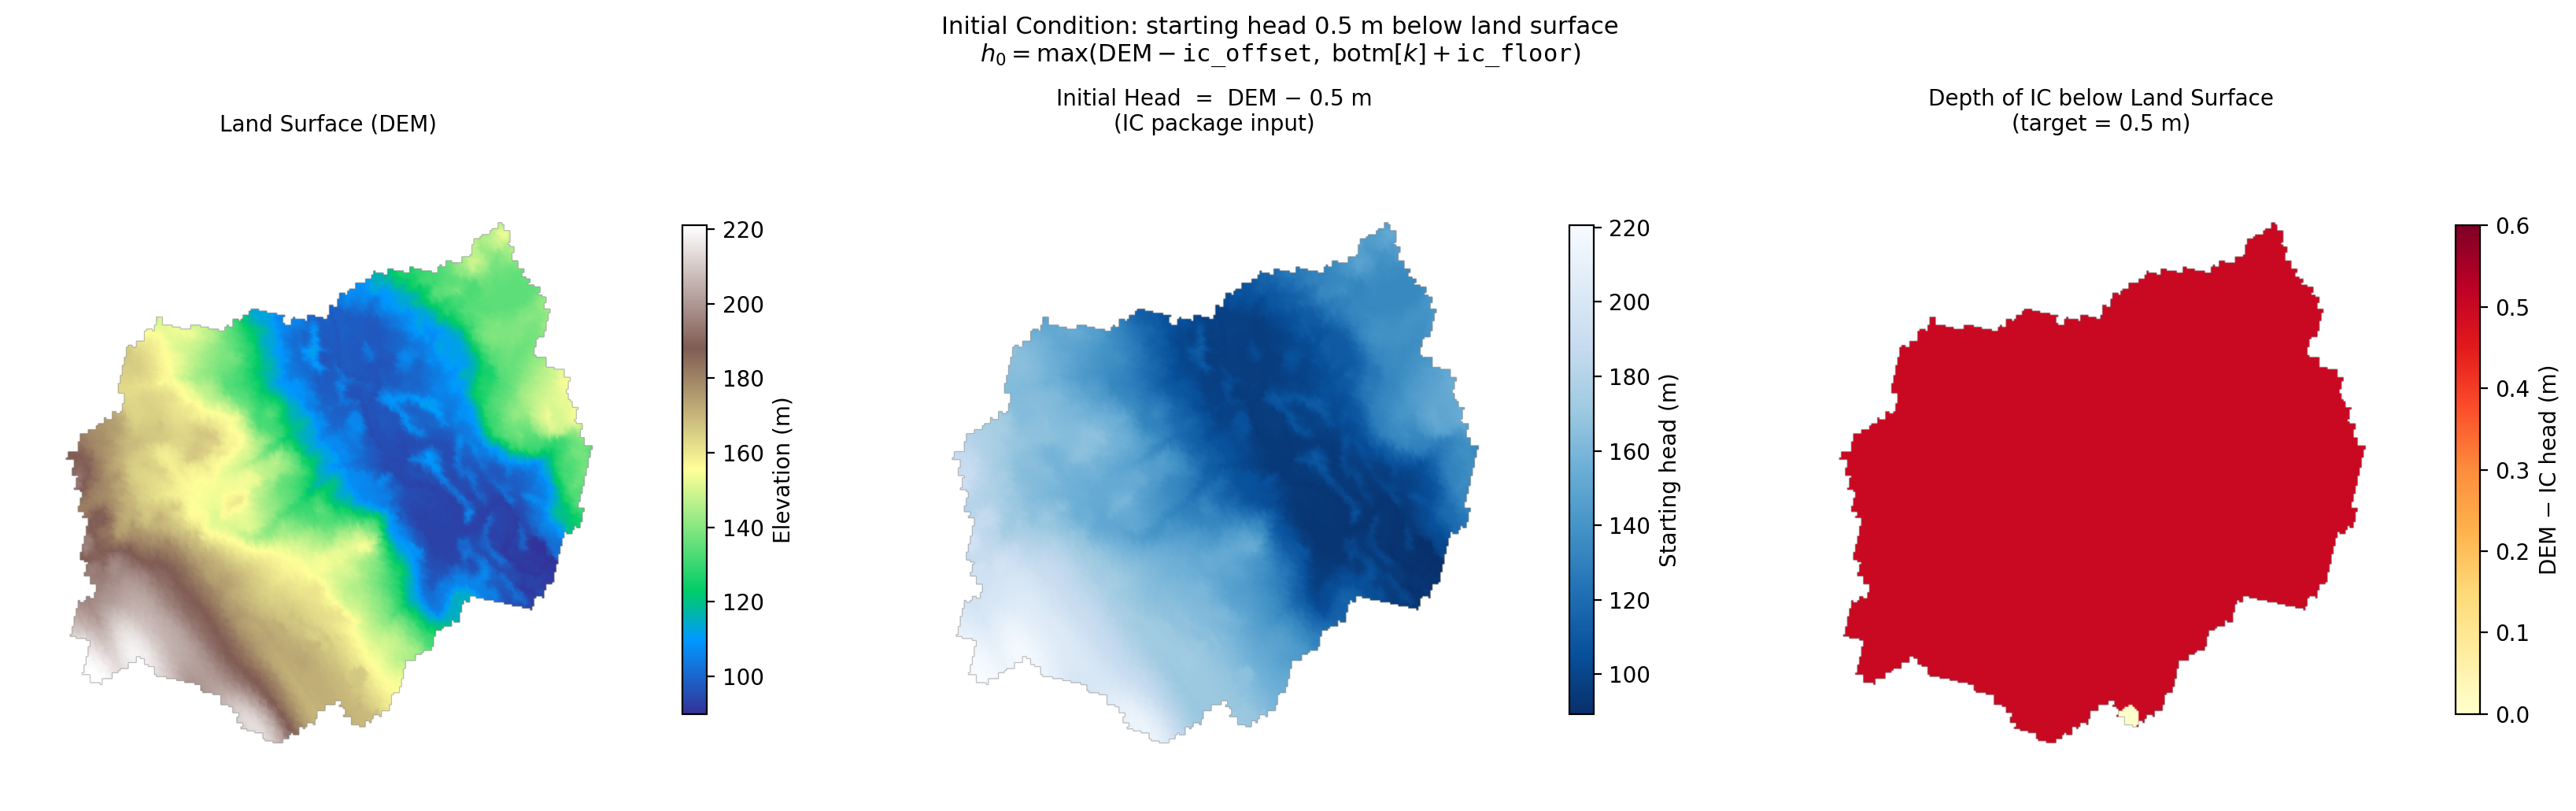

IC head range  : 89.4 – 220.5 m
Depth below DEM: -0.300 – 0.500 m


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ax = axes[0]
im0 = ax.imshow(np.where(active, dem, np.nan), cmap='terrain', origin='upper')
plt.colorbar(im0, ax=ax, shrink=0.75, label='Elevation (m)')
ax.set_title('Land Surface (DEM)', fontsize=10)
ax.axis('off')

ax = axes[1]
strt_plot = strt_2d.copy(); strt_plot[inactive_mask] = np.nan
im1 = ax.imshow(strt_plot, cmap='Blues_r', origin='upper')
plt.colorbar(im1, ax=ax, shrink=0.75, label='Starting head (m)')
ax.set_title(f'Initial Head  =  DEM − {ic_offset} m\n(IC package input)', fontsize=10)
ax.axis('off')

ax = axes[2]
depth_offset = np.where(active, dem - strt_2d, np.nan)
im2 = ax.imshow(depth_offset, cmap='YlOrRd', origin='upper', vmin=0, vmax=ic_offset * 1.2)
plt.colorbar(im2, ax=ax, shrink=0.75, label='DEM − IC head (m)')
ax.set_title(f'Depth of IC below Land Surface\n(target = {ic_offset} m)', fontsize=10)
ax.axis('off')

plt.suptitle(
    f'Initial Condition: starting head {ic_offset} m below land surface\n'
    r'$h_0 = \max(\mathrm{DEM} - \mathtt{ic\_offset},\; \mathrm{botm}[k] + \mathtt{ic\_floor})$',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

print(f'IC head range  : {np.nanmin(strt_plot):.1f} – {np.nanmax(strt_plot):.1f} m')
print(f'Depth below DEM: {np.nanmin(depth_offset):.3f} – {np.nanmax(depth_offset):.3f} m')

In [13]:
K_3d = np.zeros((nlay, nrow, ncol))
K_3d[0] = K_lay1
K_3d[1] = K_lay2
for k in range(nlay):
    K_3d[k, inactive_mask] = 1e-6

# Write icelltype as explicit INTERNAL 3D array (all 1 = convertible).
# Using scalar [1,1] triggers a CONSTANT keyword in the NPF file which
# causes a SIGILL crash in MF6 6.6.3 with Newton+UR on certain platforms.
icelltype_3d = np.ones((nlay, nrow, ncol), dtype=int)

npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    icelltype=icelltype_3d,
    k  =K_3d,
    k33=K_3d,
)
print(f'NPF: both layers convertible (icelltype=1 everywhere, INTERNAL array)')


NPF: both layers convertible (icelltype=1 everywhere, INTERNAL array)


### Storage Package (STO)

| Parameter | Layer 1 (soil) | Layer 2 (regolith) | Source |
|---|---|---|---|
| Sy | SSURGO θ_s − θ_fc (spatially variable) | **0.20** | SSURGO / literature |
| Ss | 1×10⁻⁴ m⁻¹ | 1×10⁻⁴ m⁻¹ | Literature (elastic storage) |
| iconvert | 1 (convertible) | 1 (convertible) | matches NPF icelltype |

Both layers are convertible (unconfined). Newton with under-relaxation handles cells going dry.

In [14]:
sy = np.zeros((nlay, nrow, ncol))
sy_lay1_clamped = np.clip(Sy_lay1, 0.01, 0.40)
sy_lay1_clamped[inactive_mask] = 0.12
sy[0] = sy_lay1_clamped
sy[1] = 0.20

ss = np.zeros((nlay, nrow, ncol))
ss[0] = 1e-4
ss[1] = 1e-6

# Write iconvert as explicit INTERNAL 3D array (all 1 = convertible).
# Same reason as icelltype in NPF — CONSTANT keyword causes SIGILL with Newton+UR.
iconvert_3d = np.ones((nlay, nrow, ncol), dtype=int)

sto = flopy.mf6.ModflowGwfsto(
    gwf,
    storagecoefficient=False,
    iconvert=iconvert_3d,
    ss=ss, sy=sy,
    transient={0: True},
    pname='STO',
)
print(f'STO: L1 Sy={sy[0][active].mean():.3f} mean | L2 Sy=0.20')
print(f'     Both layers convertible (iconvert=1 everywhere, INTERNAL array)')


STO: L1 Sy=0.117 mean | L2 Sy=0.20
     Both layers convertible (iconvert=1 everywhere, INTERNAL array)


### Boundary Conditions — Surface Drain (DRN)

In [15]:
# DRN — Surface drain on all active Layer 1 cells.
# Conductance formula: C = K × dx × dy / (d_soil/2)  [m²/s]

rows, cols = np.where(idomain[0] == 1)
drain_elev = top[rows, cols]
drain_cond = K_lay1[rows, cols] * dx * dy / (d_soil[rows, cols] / 2)
#drain_cond = np.clip(drain_cond, 1e-8, 1e-5)   # cap at 1e-5 m²/s

drn_spd = [[0, int(r), int(c), float(e), float(cv)]
           for r, c, e, cv in zip(rows, cols, drain_elev, drain_cond)]

drn = flopy.mf6.ModflowGwfdrn(gwf, stress_period_data={0: drn_spd},
                                pname='DRN', save_flows=True)
print(f'DRN: {len(drn_spd)} cells')
print(f'  mean C = {np.mean(drain_cond):.2e} m²/s  (capped at 1e-5)')

DRN: 44003 cells
  mean C = 5.95e-03 m²/s  (capped at 1e-5)


### UZF — Unsaturated Zone Flow ─

In [16]:
# ── UZF — Unsaturated Zone Flow ──────────────────────────────────
EXT_DEPTH = 1.5    # ET extinction depth (m below surface)
EXT_WC    = 0.05   # ET extinction water content (minimum θ for ET)
EPS       = 3.5    # Brooks-Corey epsilon (pore-size distribution)

# HA, HROOT, ROOTACT are required in period data when simulate_et=True,
# but only USED if unsat_etae=True (air-entry ET model, needs calibration).
# We use unsat_etwc=True instead: simpler water-content threshold approach
# controlled only by EXTDP and EXTWC — no additional calibration needed.
# These values are placeholders (required by MF6 format, not used):
HA      =   0.0    # m   (not used — unsat_etwc, not unsat_etae)
HROOT   = -150.0   # m   (not used)
ROOTACT =   0.0    # not used

rows_uzf, cols_uzf = np.where(idomain[0] == 1)
n_uzf = len(rows_uzf)

# Package data: [iuzno, cellid, landflag, ivertcon, surfdep, vks, thtr, thts, thti, eps]
uzf_pd = [
    [iuzno, (0, int(r), int(c)), 1, -1, 0.001,
     float(K_lay1[r, c]), float(thtr_arr[r, c]),
     float(thts_arr[r, c]), float(thti_arr[r, c]), EPS]
    for iuzno, (r, c) in enumerate(zip(rows_uzf, cols_uzf))
]

# Period data: 8 columns — [iuzno, finf, pet, extdp, extwc, ha, hroot, rootact]
iuzno_arr = np.arange(n_uzf)
uzf_spd   = {}
for i in range(nper):
    data = np.column_stack([
        iuzno_arr,
        np.full(n_uzf, finf_m_s[i]),
        np.full(n_uzf, pet_m_s[i]),
        np.full(n_uzf, EXT_DEPTH),
        np.full(n_uzf, EXT_WC),
        np.full(n_uzf, HA),
        np.full(n_uzf, HROOT),
        np.full(n_uzf, ROOTACT),
    ])
    uzf_spd[i] = data.tolist()

uzf = flopy.mf6.ModflowGwfuzf(
    gwf, nuzfcells=n_uzf, ntrailwaves=7, nwavesets=40,
    simulate_et=True,
    unsat_etwc=True,     # UZ ET = linear between EXTDP/EXTWC — no HA/HROOT/ROOTACT needed
    linear_gwet=False,   # GW ET off — WT mostly deeper than EXTDP
    simulate_gwseep=False,
    packagedata=uzf_pd, perioddata=uzf_spd,
    budget_filerecord=f'{name}.uzfbud', pname='UZF',
)
print(f'UZF: {n_uzf} cells  |  {nper} monthly stress periods')
print(f'  ET model : UNSAT_ETWC  (θ > EXTWC={EXT_WC} within EXTDP={EXT_DEPTH} m)')
print(f'  EXTDP={EXT_DEPTH} m  |  EXTWC={EXT_WC}')
print(f'  finf range: {finf_m_s.min():.2e} – {finf_m_s.max():.2e} m/s')

UZF: 44003 cells  |  12 monthly stress periods
  ET model : UNSAT_ETWC  (θ > EXTWC=0.05 within EXTDP=1.5 m)
  EXTDP=1.5 m  |  EXTWC=0.05
  finf range: 1.33e-08 – 8.37e-08 m/s


### Pumping Well (WEL)

The pumping well location is read from `pumping_well.shp`. The well is placed in **Layer 2** (regolith aquifer), which is the productive zone for domestic/municipal wells in this setting.

Pumping rate is read from the shapefile attribute (field `pump_m3s`, `rate`, or similar). If no rate column is found, a default of **0 m³/s** is used — update the shapefile attribute to set the actual rate.

Wells: 2 total | CRS: PROJCS["WGS 84 / UTM zone 18N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32618"]]
   id                        geometry
0   1  POINT (729608.507 4633921.393)
1   2  POINT (729743.372 4634003.728)

Pumping well (id=1) → row 194, col 229  |  Q = 0 m³/s
Monitoring well (id=2) → row 185, col 244

WEL: pumping well active in all 12 daily periods


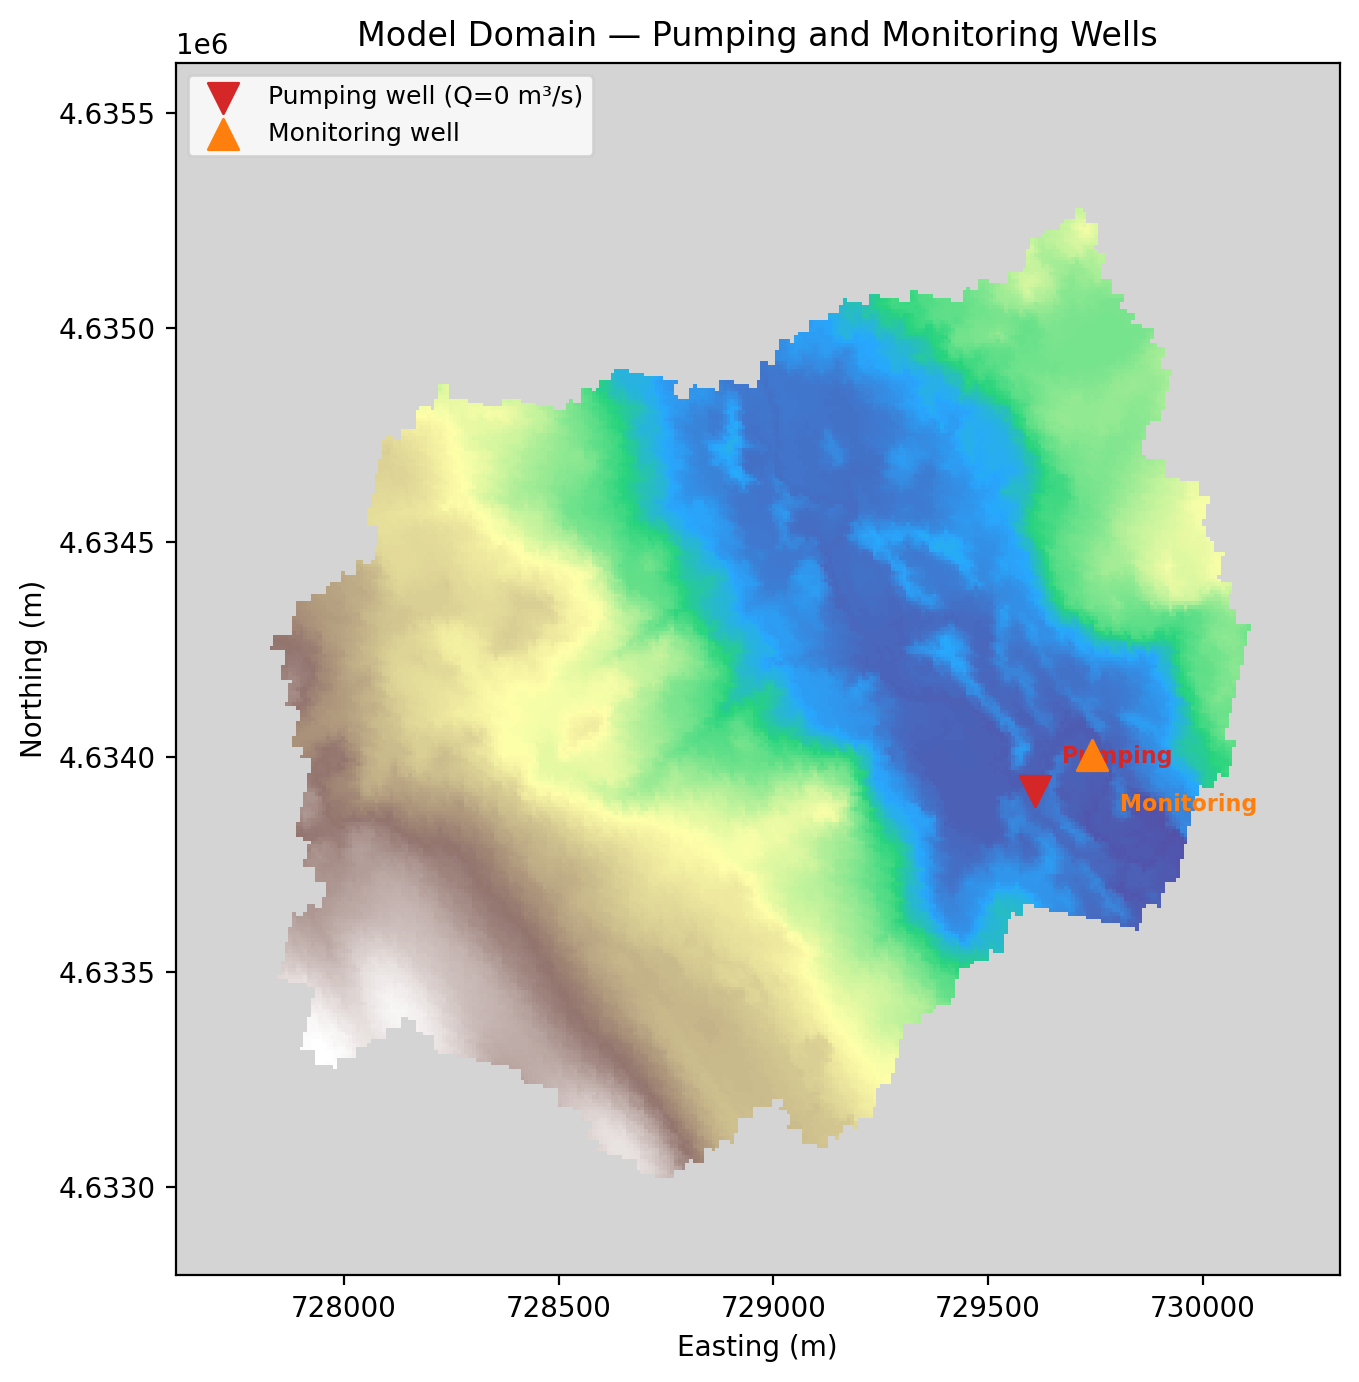

In [17]:
well_gdf = gpd.read_file(str(data_dir / 'pumping_well.shp')).to_crs(dem_crs)
print(f'Wells: {len(well_gdf)} total | CRS: {well_gdf.crs}')
print(well_gdf[['id', 'geometry']].to_string())

# ── Assign well roles (swap ids if needed) ────────────────────────
PUMP_ID  = 1  
pump_well = well_gdf[well_gdf['id'] == PUMP_ID].iloc[0]
mon_wells = well_gdf[well_gdf['id'] != PUMP_ID]

# ── Locate pumping well on model grid ─────────────────────────────
px, py = pump_well.geometry.x, pump_well.geometry.y
p_col  = int(np.clip((px - xmin) / dx, 0, ncol - 1))
p_row  = int(np.clip((ymax - py) / dy, 0, nrow - 1))
q_pump = 0   # m³/s (negative = extraction); update if known

print(f'\nPumping well (id={PUMP_ID}) → row {p_row}, col {p_col}  |  Q = {q_pump} m³/s')
for _, mw in mon_wells.iterrows():
    mx, my = mw.geometry.x, mw.geometry.y
    mc = int(np.clip((mx - xmin) / dx, 0, ncol - 1))
    mr = int(np.clip((ymax - my) / dy, 0, nrow - 1))
    print(f'Monitoring well (id={mw["id"]}) → row {mr}, col {mc}')

# ── WEL package — pumping well only, Layer 2, all 365 periods ─────
wel_spd_list = [(1, p_row, p_col, q_pump)]
wel_spd      = {i: wel_spd_list for i in range(nper)}
wel = flopy.mf6.ModflowGwfwel(gwf, stress_period_data=wel_spd,
                                pname='WEL', save_flows=True)
print(f'\nWEL: pumping well active in all {nper} daily periods')

# ── Map: domain + both wells ───────────────────────────────────────
extent = [xmin, xmin + ncol*dx, ymin, ymin + nrow*dy]

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(np.where(active, dem, np.nan),
          cmap='terrain', origin='upper', extent=extent, alpha=0.85)
ax.imshow(np.where(~active, 0.5, np.nan),
          cmap='Greys', origin='upper', extent=extent, vmin=0, vmax=1, alpha=0.4)

# Pumping well
ax.scatter(px, py, s=120, c='C3', marker='v', zorder=6,
           label=f'Pumping well (Q={q_pump} m³/s)')
ax.annotate(f'Pumping', xy=(px, py),
            xytext=(10, 10), textcoords='offset points',
            fontsize=8, color='C3', fontweight='bold')

# Monitoring well(s)
for _, mw in mon_wells.iterrows():
    mx, my = mw.geometry.x, mw.geometry.y
    ax.scatter(mx, my, s=120, c='C1', marker='^', zorder=6,
               label=f'Monitoring well')
    ax.annotate(f'Monitoring', xy=(mx, my),
                xytext=(10, -20), textcoords='offset points',
                fontsize=8, color='C1', fontweight='bold')

ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
ax.set_title('Model Domain — Pumping and Monitoring Wells')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout(); plt.show()

In [18]:
oc = flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord  =f'{name}.hds',
    budget_filerecord=f'{name}.cbc',
    saverecord=[('HEAD', 'LAST'), ('BUDGET', 'LAST')],  # one record per month
)
gwf.name_file.save_flows = True
print('OC: saving HEAD and BUDGET at end of each month (12 records)')

OC: saving HEAD and BUDGET at end of each month (12 records)


## 5. Write and Run

In [19]:
sim.write_simulation()
success, buff = sim.run_simulation(silent=False)

if success:
    print('\n✓ Simulation completed successfully!')
else:
    print('\n✗ Simulation FAILED — last 40 lines of listing file:')
    lst = ws / f'{name}.lst'
    if lst.exists():
        print('\n'.join(lst.read_text().splitlines()[-40:]))

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing package tr_datadriven.ats...
  writing model tr_datadriven...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package sto...
    writing package drn...
INFORMATION: maxbound in ('', 'drn', 'dimensions') changed to 44003 based on size of stress_period_data
    writing package uzf...
    writing package wel...
INFORMATION: maxbound in ('', 'wel', 'dimensions') changed to 1 based on size of stress_period_data
    writing package oc...
FloPy is using the following executable to run the model: ../../../../bin/mf6
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.3 09/29/2025

        MODFLOW 6 compiled Oct  7 2025 22:50:01 with GCC version 12.4.0

This software has been approved for

## 6. Post-Processing and Characterization

In [21]:
hobj          = gwf.output.head()
kstpkper_list = hobj.get_kstpkper()
month_labels  = [pd.Timestamp(f'2025-{m:02d}-01') for m in range(1, 13)]
print(f'Saved head records: {len(kstpkper_list)}  (one per month, Jan–Dec 2025)')

Saved head records: 12  (one per month, Jan–Dec 2025)


### 6a. Hydraulic Head — January (First Month) and Head Change Through 2025

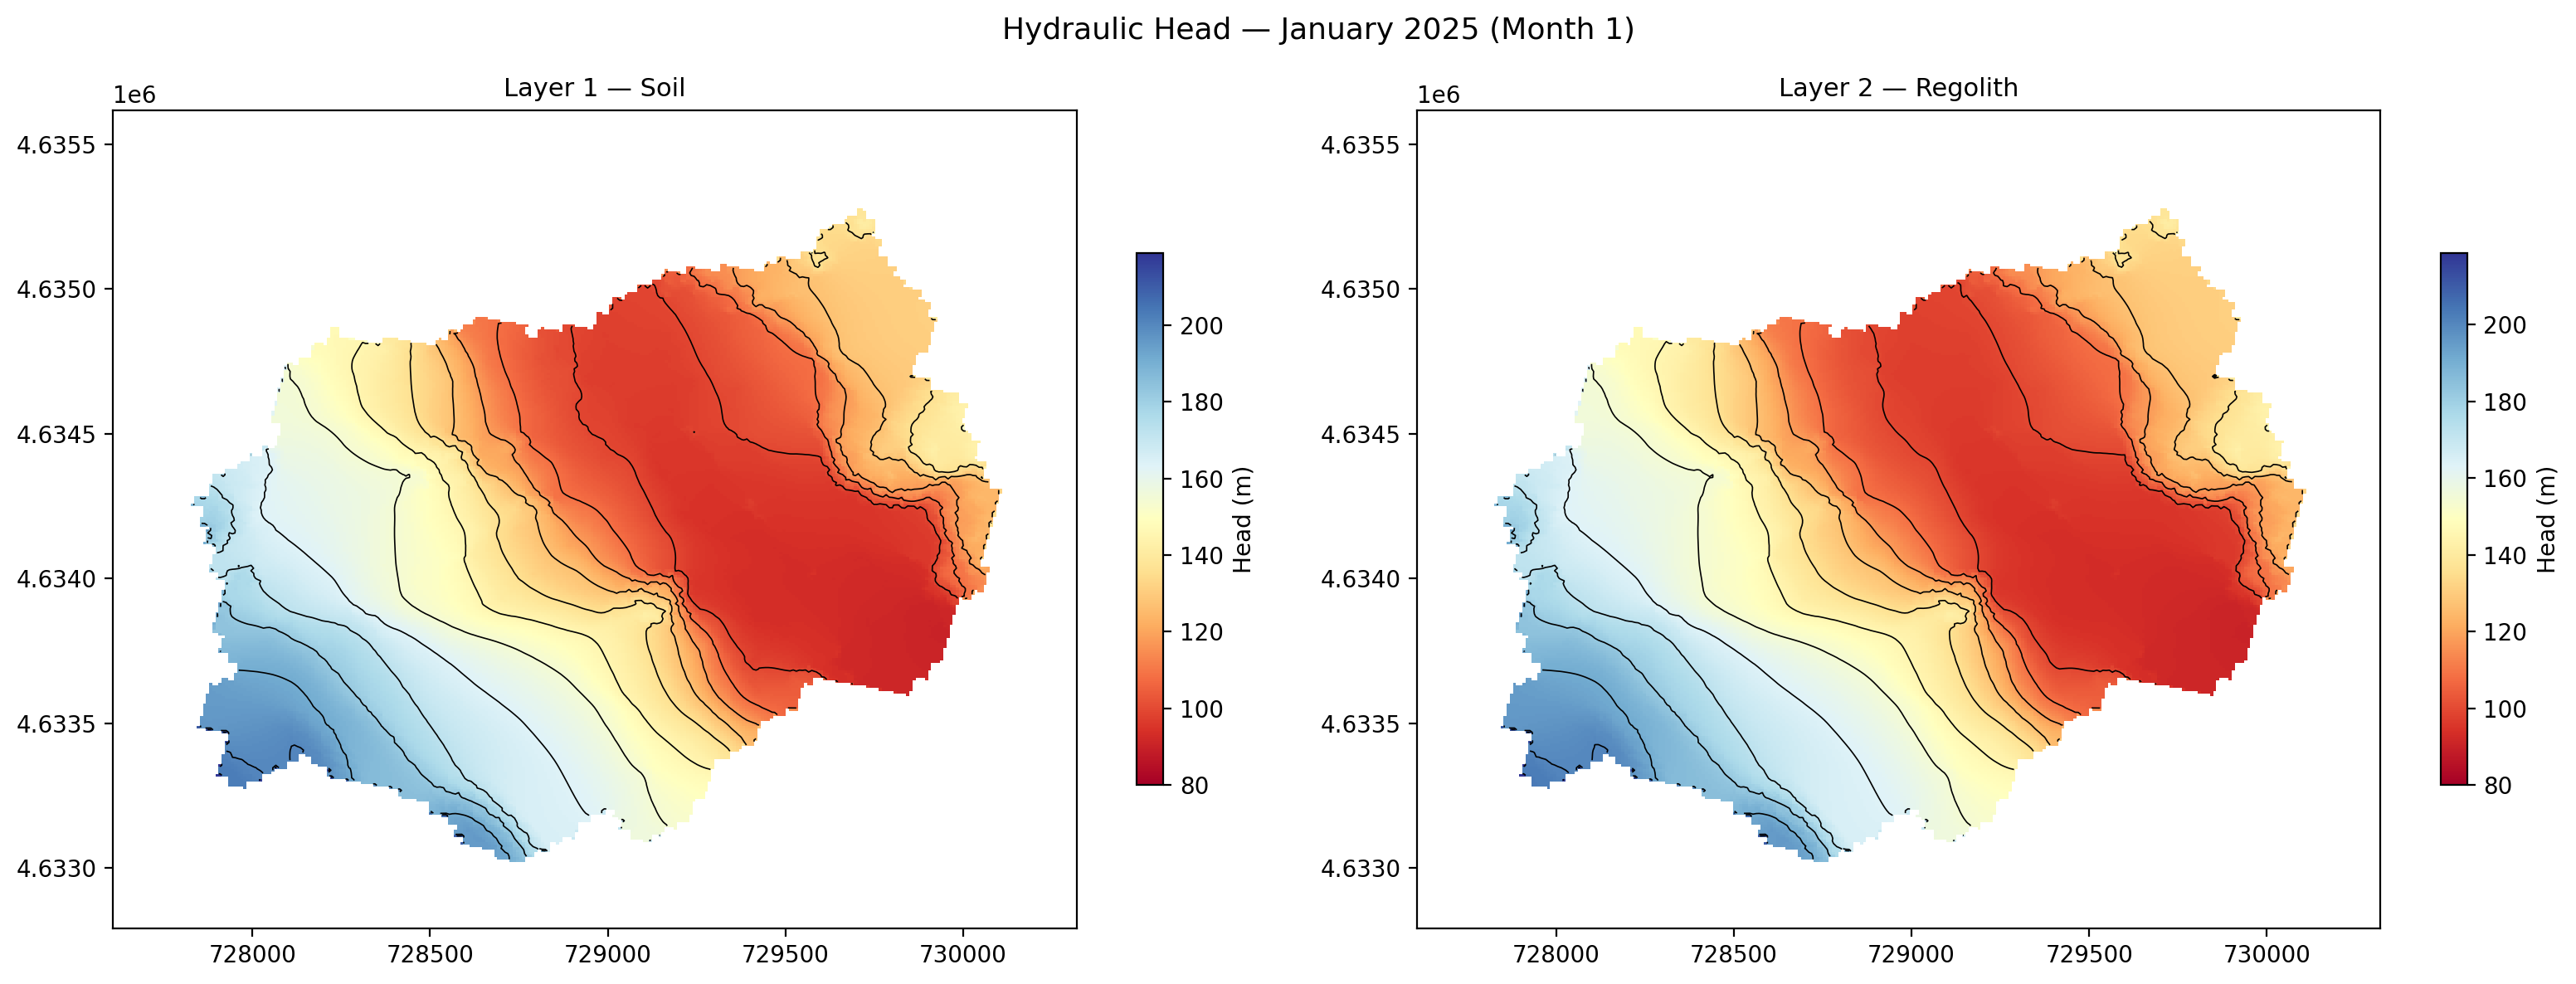

In [22]:
# January head — both layers, same format as notebook 05
hds_jan = hobj.get_data(kstpkper=kstpkper_list[1]).astype(float)
hds_jan[hds_jan > 1e29] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, lyr, title in zip(axes, [0, 1], ['Layer 1 — Soil', 'Layer 2 — Regolith']):
    mm = PlotMapView(model=gwf, layer=lyr, ax=ax)
    cb = mm.plot_array(hds_jan, cmap='RdYlBu', vmin=80)
    levels = np.linspace(np.nanmin(hds_jan[lyr]), np.nanmax(hds_jan[lyr]), 15)
    mm.contour_array(hds_jan, levels=levels, colors='k', linewidths=0.6)
    plt.colorbar(cb, ax=ax, shrink=0.65).set_label('Head (m)')
    ax.set_title(title, fontsize=11)

plt.suptitle('Hydraulic Head — January 2025 (Month 1)', fontsize=13)
plt.tight_layout(); plt.show()

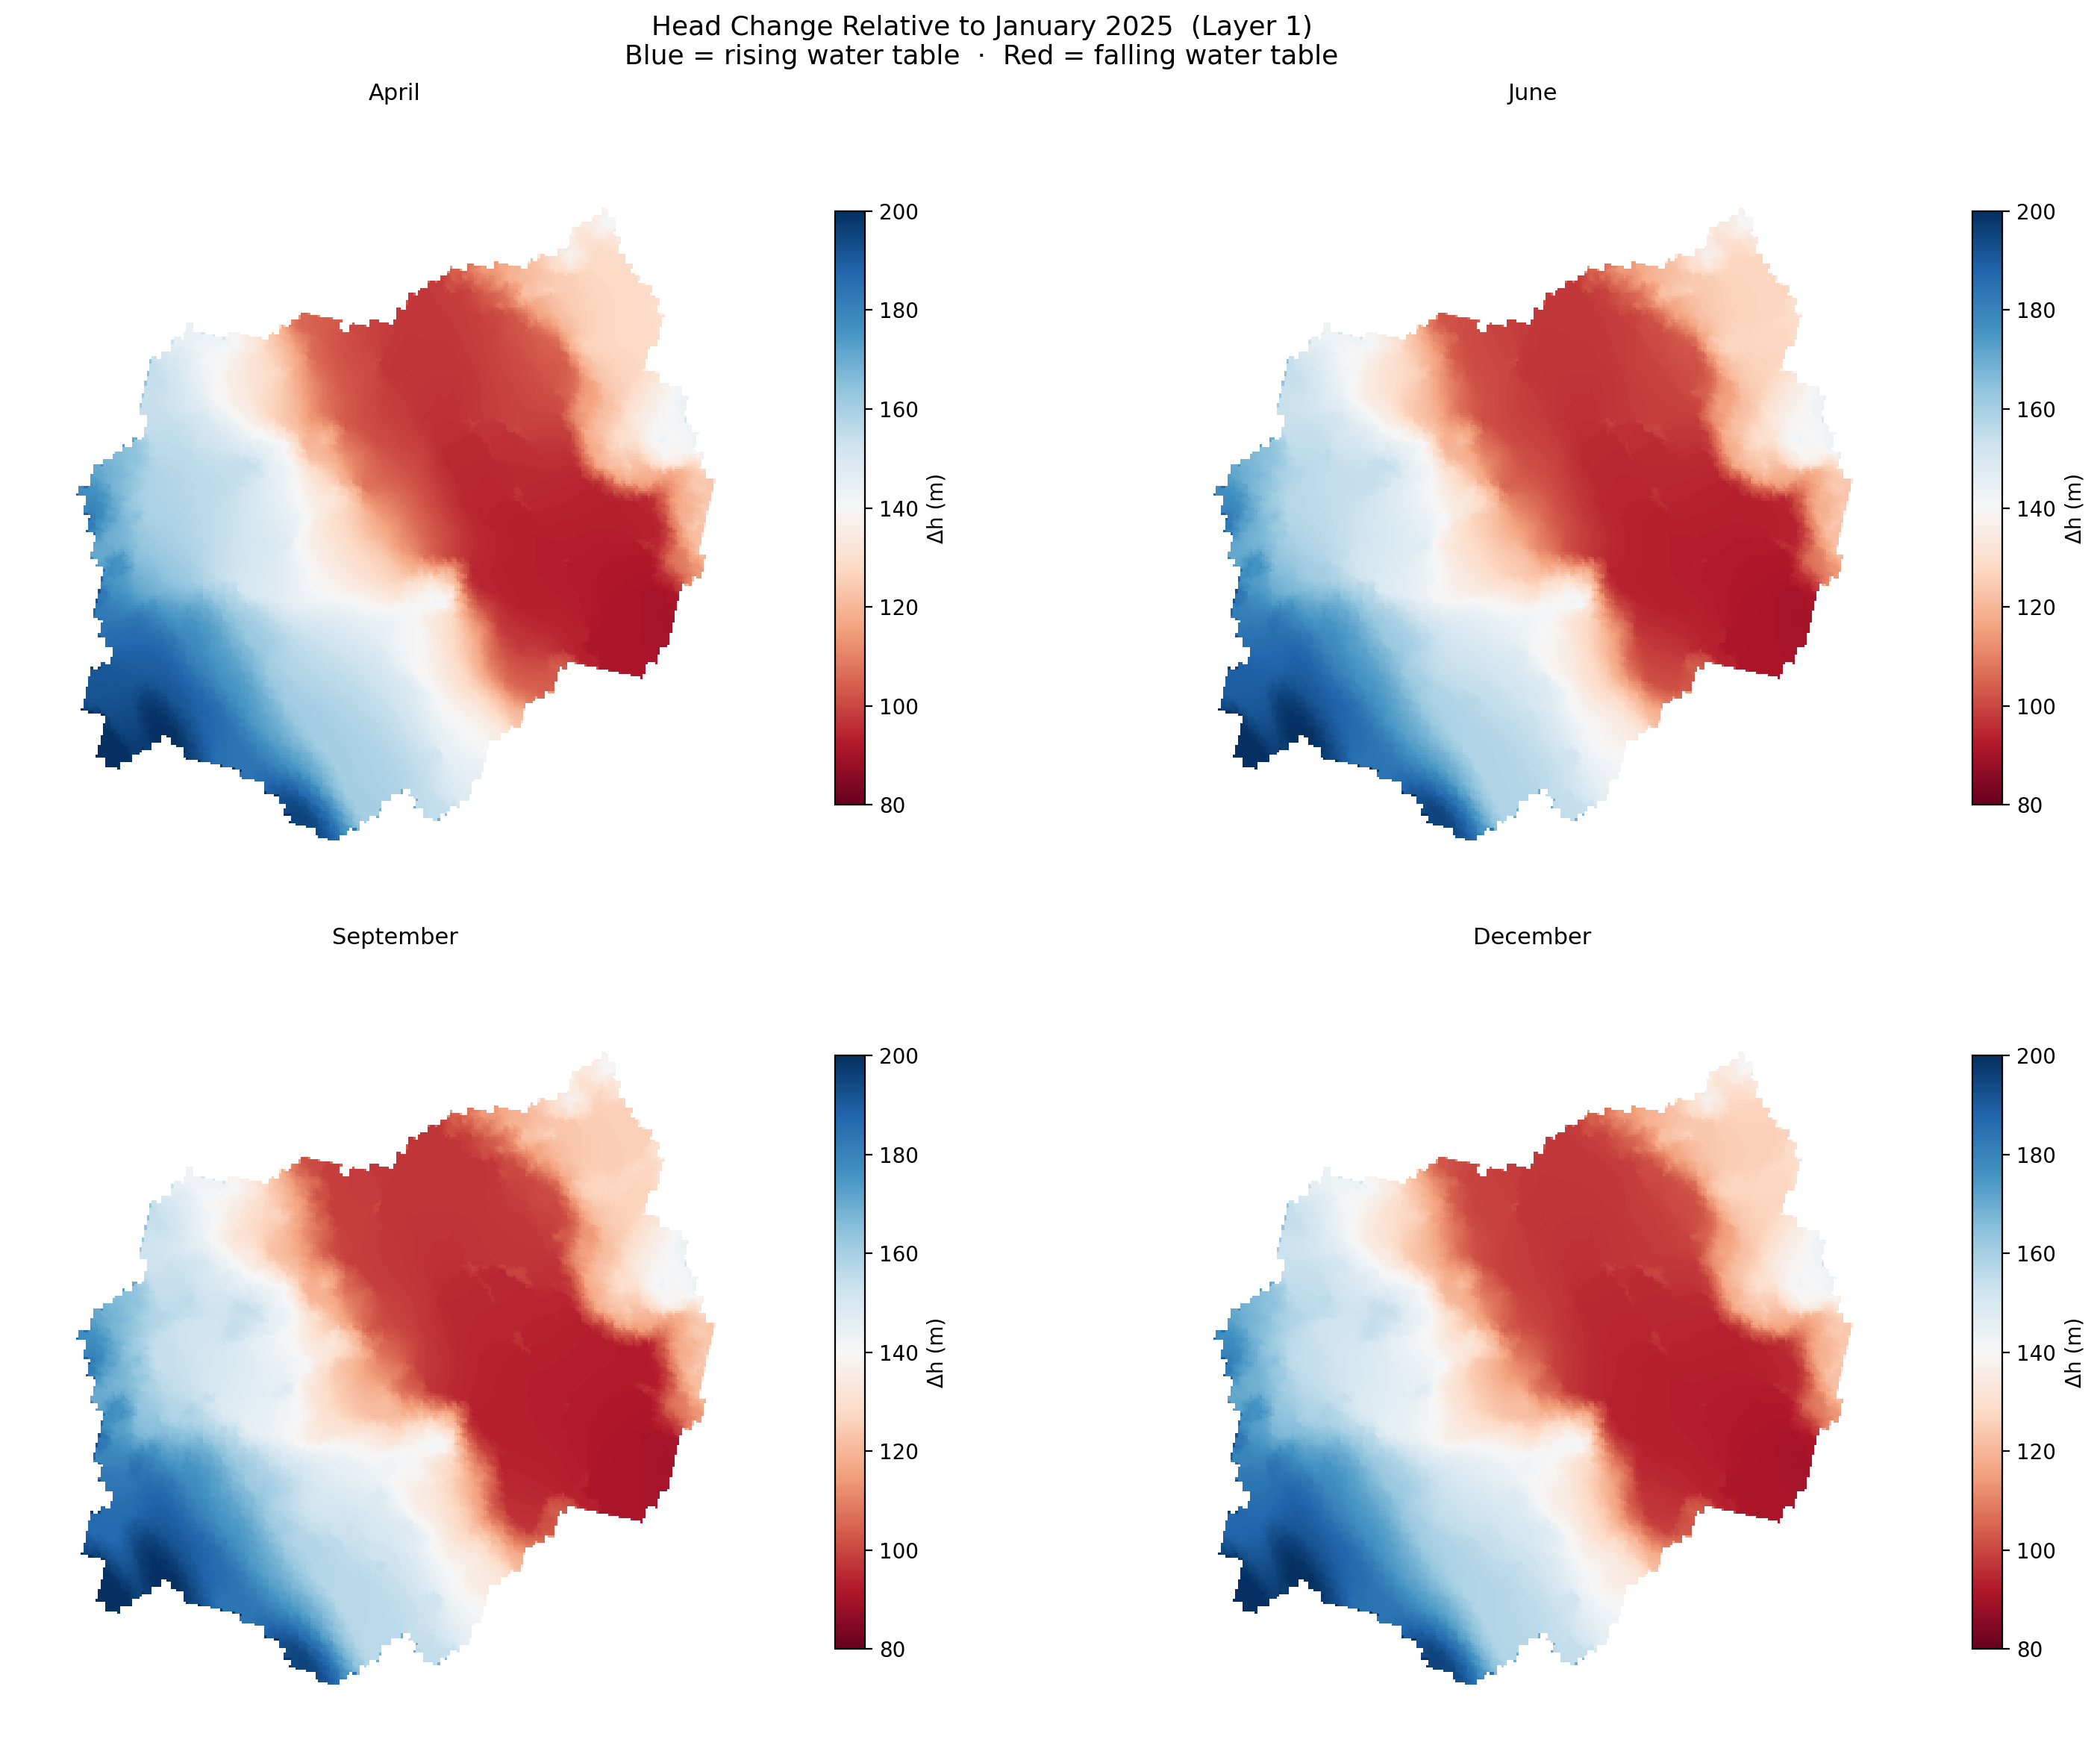

In [52]:
# Head change relative to January:  Δh = h[month] − h[Jan]
# Blue = rising water table,  Red = falling water table
snap_idx   = [3, 5, 8, 11]   # Apr, Jun, Sep, Dec (0-based)
snap_names = [calendar.month_name[m] for m in [4, 6, 9, 12]]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, mi, name in zip(axes.flat, snap_idx, snap_names):
    hds_m = hobj.get_data(kstpkper=kstpkper_list[mi]).astype(float)
    hds_m[hds_m > 1e29] = np.nan

    im = ax.imshow(hds_m[0], cmap='RdBu', vmin = 80,vmax = 200, origin='upper')
    plt.colorbar(im, ax=ax, shrink=0.75).set_label('Δh (m)')
    ax.set_title(f'{name}', fontsize=11)
    ax.axis('off')

plt.suptitle(
    'Head Change Relative to January 2025  (Layer 1)\n'
    'Blue = rising water table  ·  Red = falling water table',
    fontsize=13
)
plt.tight_layout(); plt.show()

### 6b. Head Time Series at Observation Wells

Observation points (Layer 2 — regolith):
  Mon-2: row=185, col=244
  Pump-1: row=194, col=229


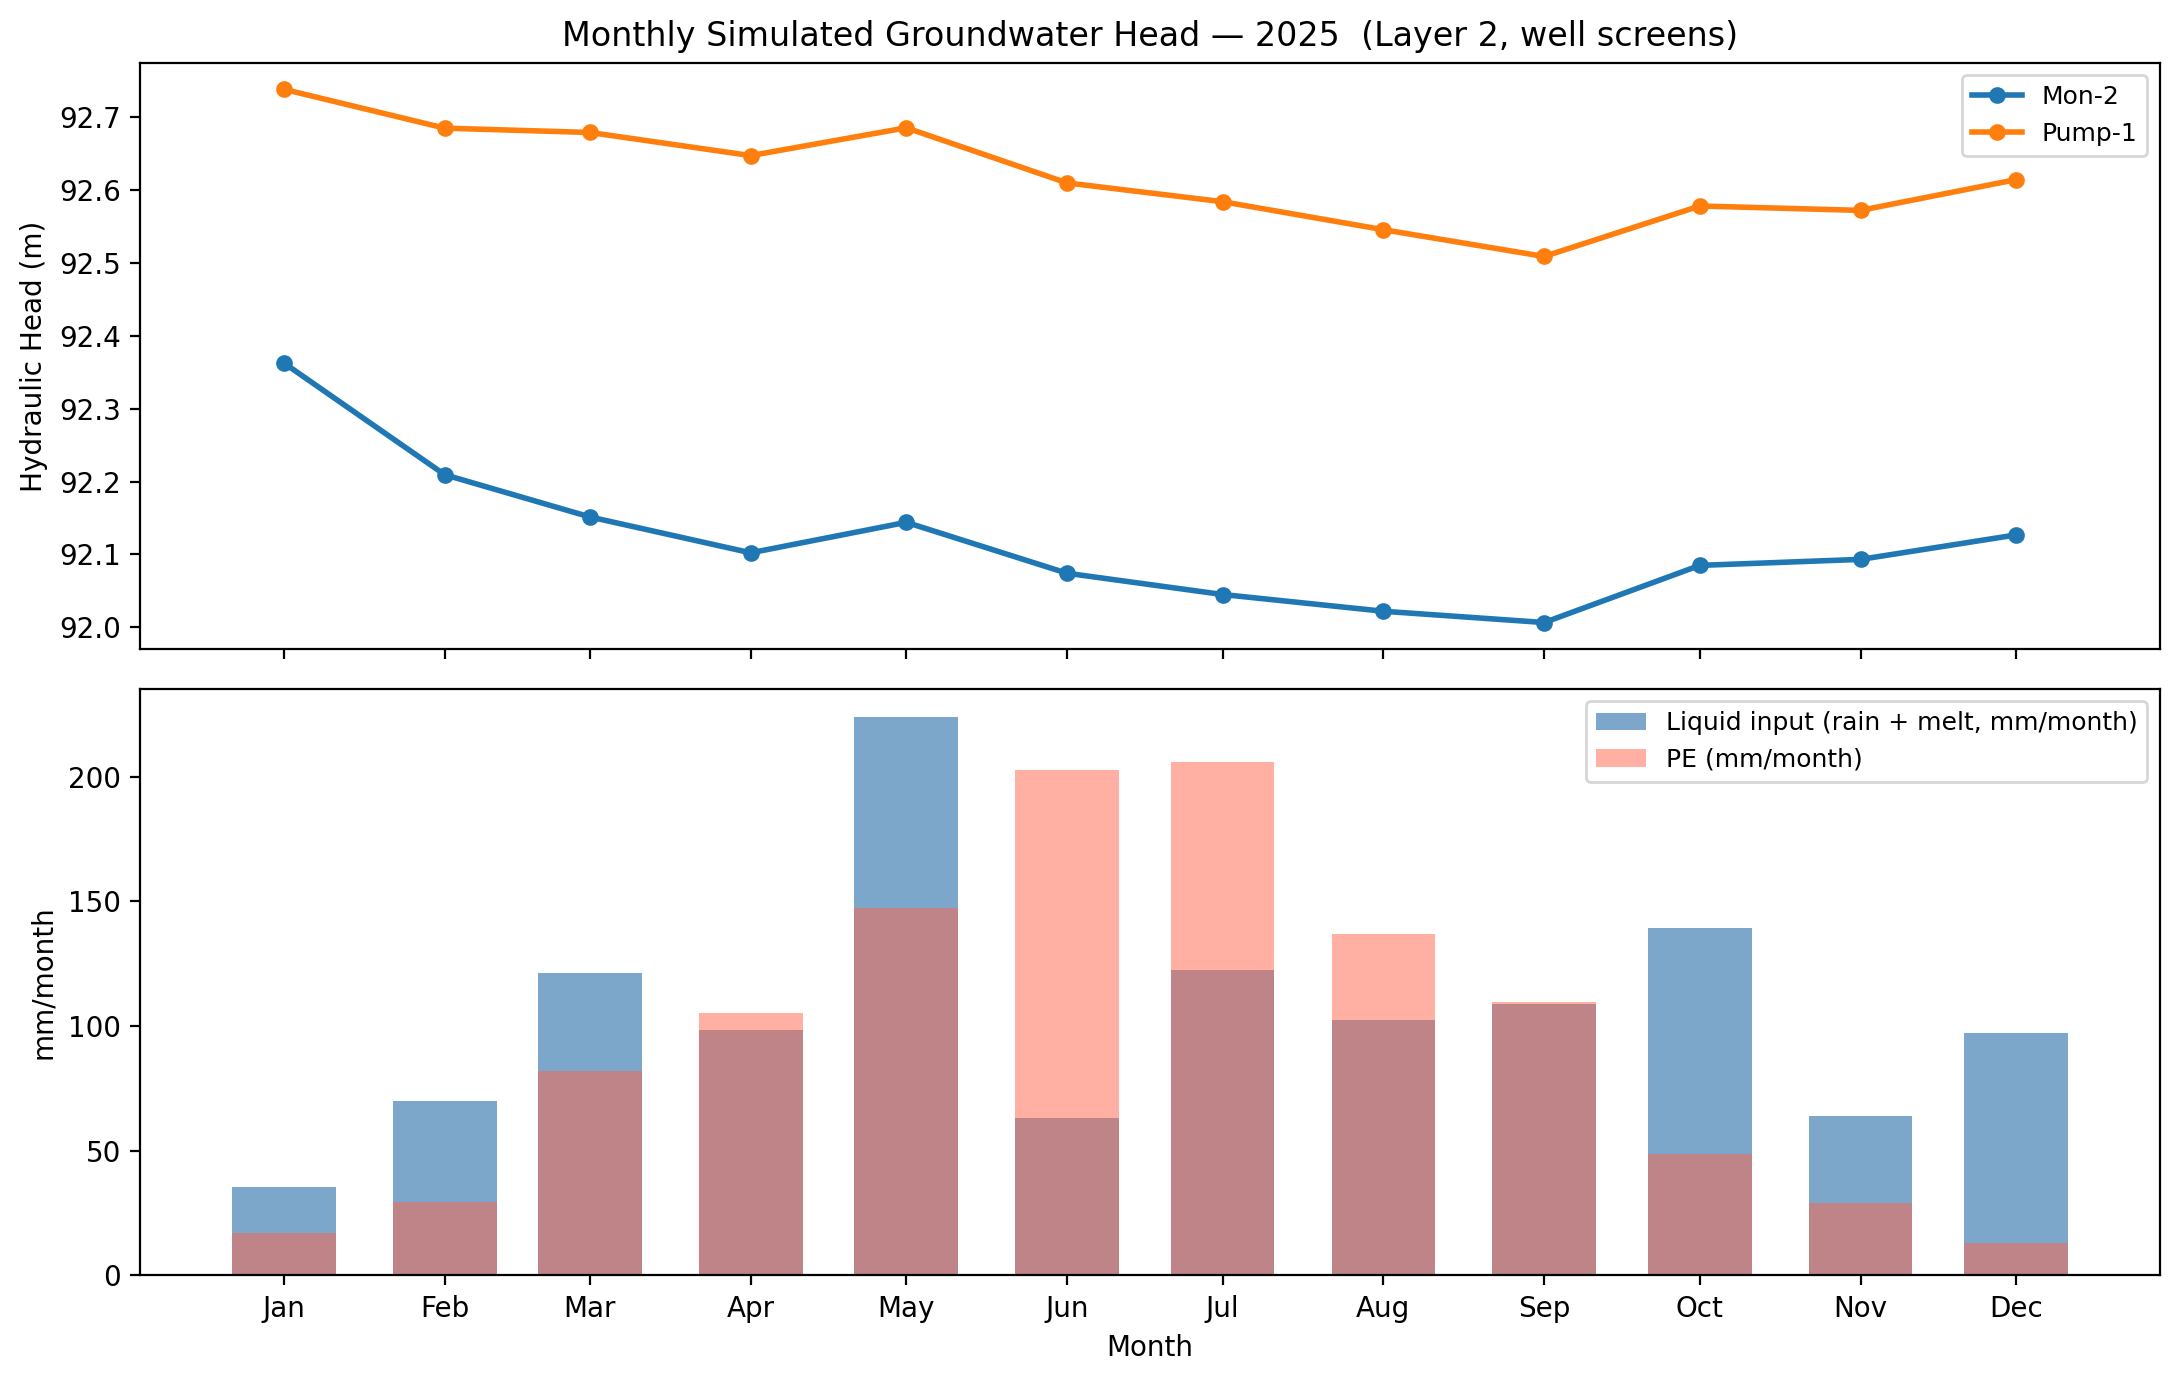

Seasonal amplitude (max − min, 2025):
  Mon-2: 0.36 m
  Pump-1: 0.23 m


In [54]:
# ── Observation points: actual monitoring wells from shapefile ────
# Wells are screened in Layer 2 (regolith) — use layer index 1.
obs_pts = {}
for _, mw in mon_wells.iterrows():
    mx, my = mw.geometry.x, mw.geometry.y
    mc = int(np.clip((mx - xmin) / dx, 0, ncol - 1))
    mr = int(np.clip((ymax - my) / dy, 0, nrow - 1))
    obs_pts[f'Mon-{int(mw["id"])}'] = (1, mr, mc)   # layer 2 = index 1

# Also include the pumping well itself (layer 2)
obs_pts[f'Pump-{PUMP_ID}'] = (1, p_row, p_col)

print('Observation points (Layer 2 — regolith):')
for pt_name, (k, r, c) in obs_pts.items():
    print(f'  {pt_name}: row={r}, col={c}')

# ── Extract monthly head at each well ────────────────────────────
h_ts = {pt: [] for pt in obs_pts}
for ksp in kstpkper_list:
    h = hobj.get_data(kstpkper=ksp).astype(float)
    h[h > 1e29] = np.nan
    for pt_name, (k, r, c) in obs_pts.items():
        h_ts[pt_name].append(h[k, r, c])
h_df = pd.DataFrame(h_ts, index=month_labels)

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

colors = [f'C{i}' for i in range(len(obs_pts))]
for pt_name, color in zip(obs_pts, colors):
    axes[0].plot(h_df.index, h_df[pt_name], lw=2, marker='o', ms=5,
                 color=color, label=pt_name)
axes[0].set_ylabel('Hydraulic Head (m)')
axes[0].set_title('Monthly Simulated Groundwater Head — 2025  (Layer 2, well screens)')
axes[0].legend(fontsize=9)

# Bottom panel — liquid input (rain + melt) and PE
bar_x = np.array(month_labels)
axes[1].bar(bar_x, liquid_monthly, width=20, color='steelblue', alpha=0.7,
            label='Liquid input (rain + melt, mm/month)')
axes[1].bar(bar_x, pe_monthly,     width=20, color='tomato',    alpha=0.5,
            label='PE (mm/month)')
axes[1].set_ylabel('mm/month'); axes[1].set_xlabel('Month')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())

plt.tight_layout(); plt.show()

amp = h_df.max() - h_df.min()
print('Seasonal amplitude (max − min, 2025):')
for pt_name in h_df.columns:
    print(f'  {pt_name}: {amp[pt_name]:.2f} m')

### 6c. E–W Cross-Section — Wet vs. Dry Season


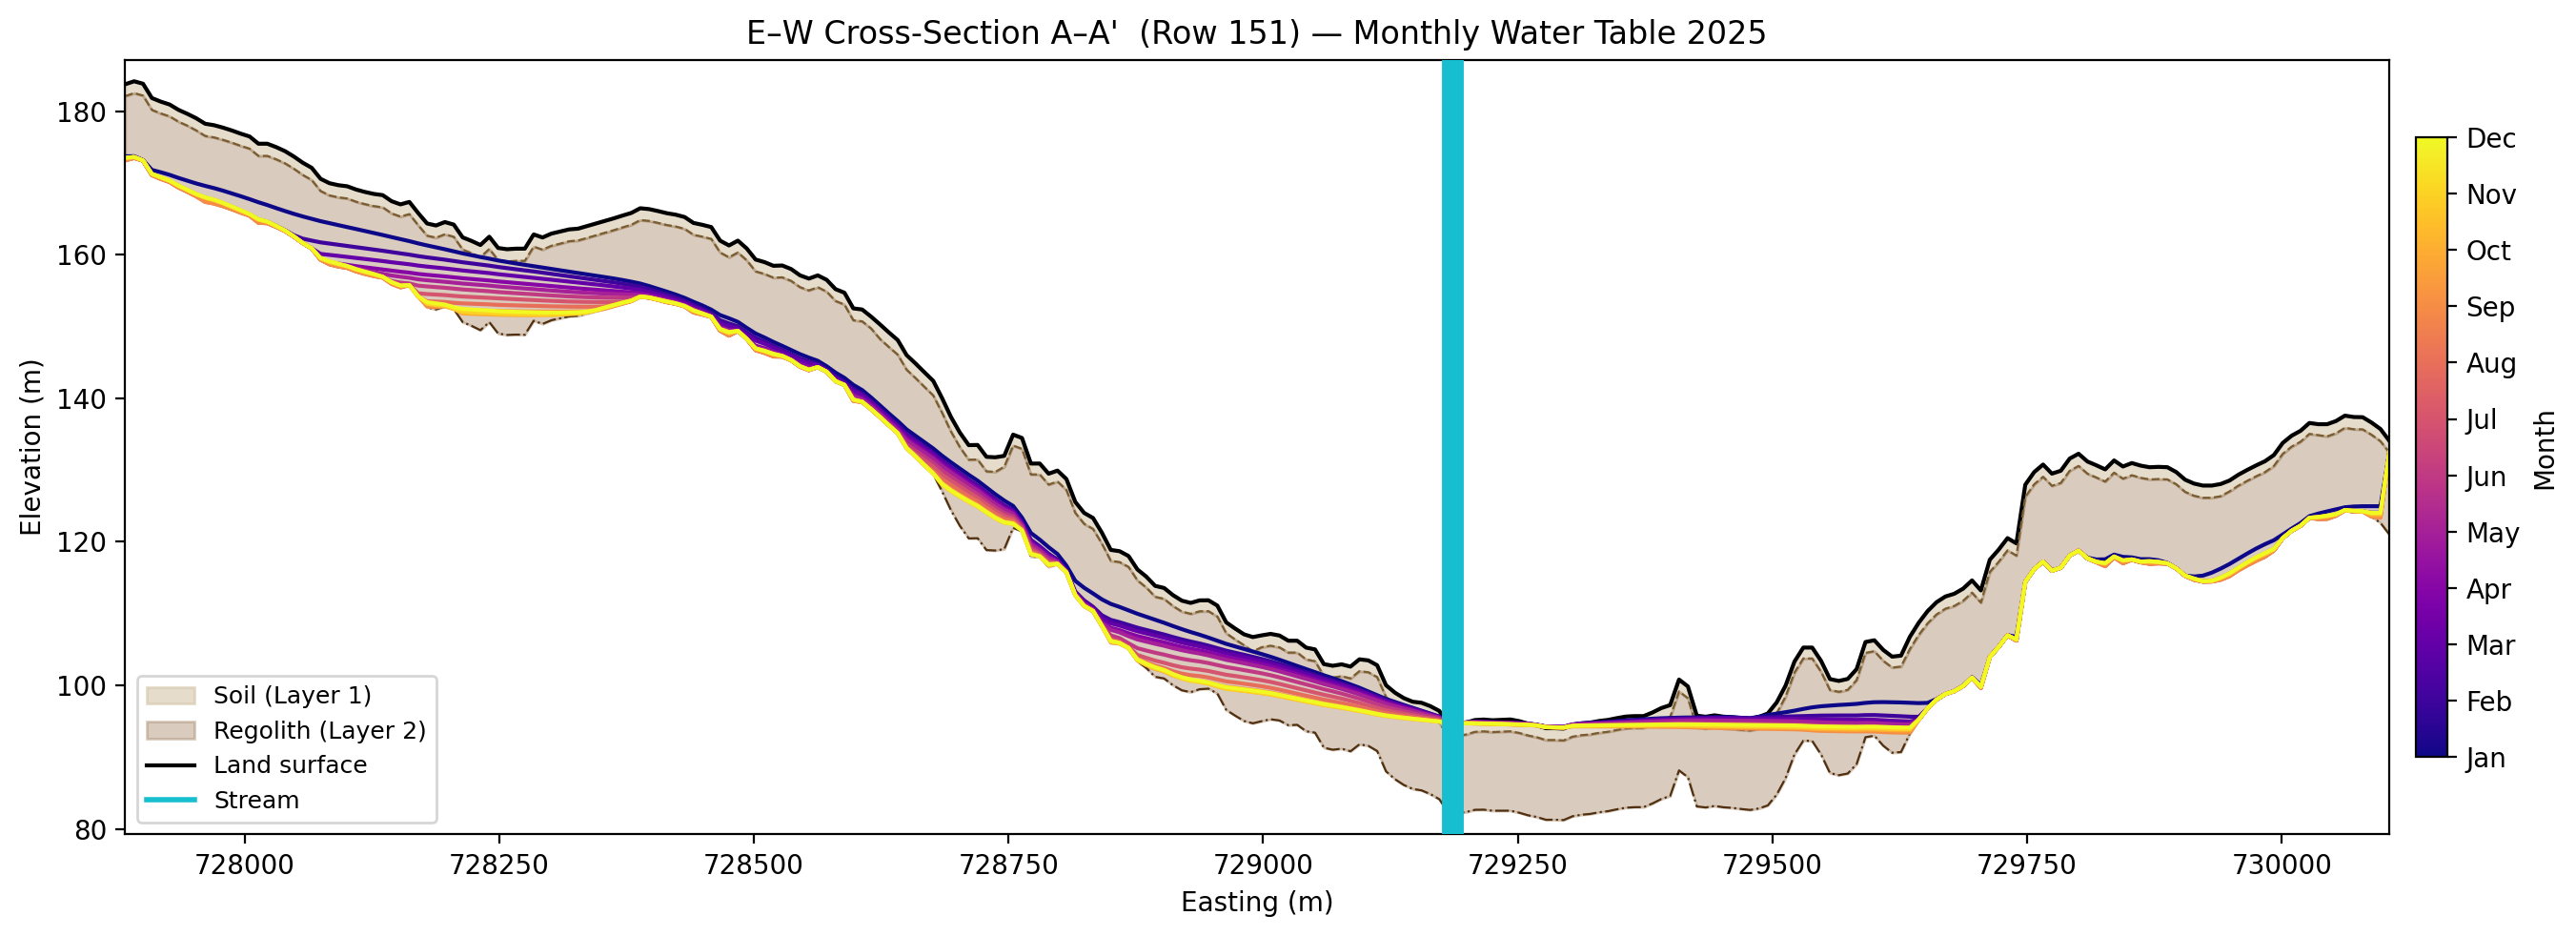

In [55]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

streams_gdf   = gpd.read_file(str(inputs_dir / 'streams_nhd.shp'))
stream_raster = rio_rasterize(
    [(geom, 1) for geom in streams_gdf.geometry],
    out_shape=(nrow, ncol), transform=dem_transform,
    fill=0, dtype='uint8', all_touched=True)

cross_row = 150

x_coords  = np.arange(ncol) * dx + xmin + dx / 2
land_surf = dem[cross_row, :]
reg_base  = botm[0, cross_row, :]
rock_base = botm[1, cross_row, :]
valid     = np.isfinite(land_surf)

# Continuous colormap: blue (Jan) → yellow (Jul) → purple (Dec)
cmap = plt.cm.plasma
norm = Normalize(vmin=1, vmax=12)

fig, ax = plt.subplots(figsize=(15, 5))

ax.fill_between(x_coords, np.where(valid, reg_base,  np.nan),
                           np.where(valid, land_surf, np.nan),
                color='#d4c5a9', alpha=0.6, label='Soil (Layer 1)')
ax.fill_between(x_coords, np.where(valid, rock_base, np.nan),
                           np.where(valid, reg_base,  np.nan),
                color='#a08060', alpha=0.4, label='Regolith (Layer 2)')
ax.plot(x_coords, np.where(valid, land_surf, np.nan), 'k-',  lw=1.5, label='Land surface')
ax.plot(x_coords, np.where(valid, reg_base,  np.nan), '--',  color='#7a5c32', lw=0.8)
ax.plot(x_coords, np.where(valid, rock_base, np.nan), '-.',  color='#503010', lw=0.8)

for i, ksp in enumerate(kstpkper_list):
    color  = cmap(norm(i + 1))
    hds    = hobj.get_data(kstpkper=ksp).astype(float)
    hds[hds > 1e29] = np.nan
    wt_row = flopy.utils.postprocessing.get_water_table(hds).data[cross_row, :]
    ax.plot(x_coords, np.where(valid, wt_row, np.nan), lw=1.5, color=color)

# Colorbar for months
sm   = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', shrink=0.8, pad=0.01)
cbar.set_label('Month')
cbar.set_ticks(range(1, 13))
cbar.set_ticklabels([calendar.month_abbr[m] for m in range(1, 13)])

stream_cols_row = np.where(stream_raster[cross_row] == 1)[0]
for sc in stream_cols_row:
    ax.axvline(x_coords[sc], color='C9', lw=5, zorder=5)
if len(stream_cols_row):
    ax.axvline(x_coords[stream_cols_row[0]], color='C9', lw=2, zorder=5, label='Stream')

ax.set_xlim(x_coords[valid][0], x_coords[valid][-1])
ax.set_ylim(rock_base[valid].min() - 2, land_surf[valid].max() + 3)
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Elevation (m)')
ax.set_title(f"E–W Cross-Section A–A'  (Row {cross_row + 1}) — Monthly Water Table 2025")
ax.legend(fontsize=9, loc='lower left')
plt.tight_layout(); plt.show()

### 6d. Surface Drainage and Pumping Budget Over Time

CBC records  : ['STO-SS', 'STO-SY', 'FLOW-JA-FACE', 'WEL', 'DRN', 'UZF-GWRCH']
CBC kstpkper : [(21, 0), (12, 1), (7, 2), (7, 3), (7, 4), (7, 5), (7, 6), (7, 7), (8, 8), (24, 9), (7, 10), (7, 11)]
kper range   : 0 – 11  (0-based: 0=Jan … 11=Dec)
UZF records  : ['GWF', 'INFILTRATION', 'REJ-INF', 'UZET', 'STORAGE']
uzfbud kper range: 0 – 11

GW recharge   : [0.00561808 0.0384291  0.05047958 0.02435923 0.08723112 0.00276896
 0.00457207 0.00453679 0.00401108 0.1115197  0.04976569 0.10360096]
Infiltration  : [0.04450205 0.09694821 0.15119362 0.12713973 0.27967936 0.08123425
 0.15294614 0.12781919 0.14021873 0.17381662 0.08238221 0.12143322]
Annual GW recharge depth : 385.0 mm/yr  (target ~200-400 mm for CT forest)


/var/folders/bc/n9nbnrrd1m1gttddqb1hzyt00000gp/T/ipykernel_63185/328836772.py:105: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[3].legend(fontsize=9)


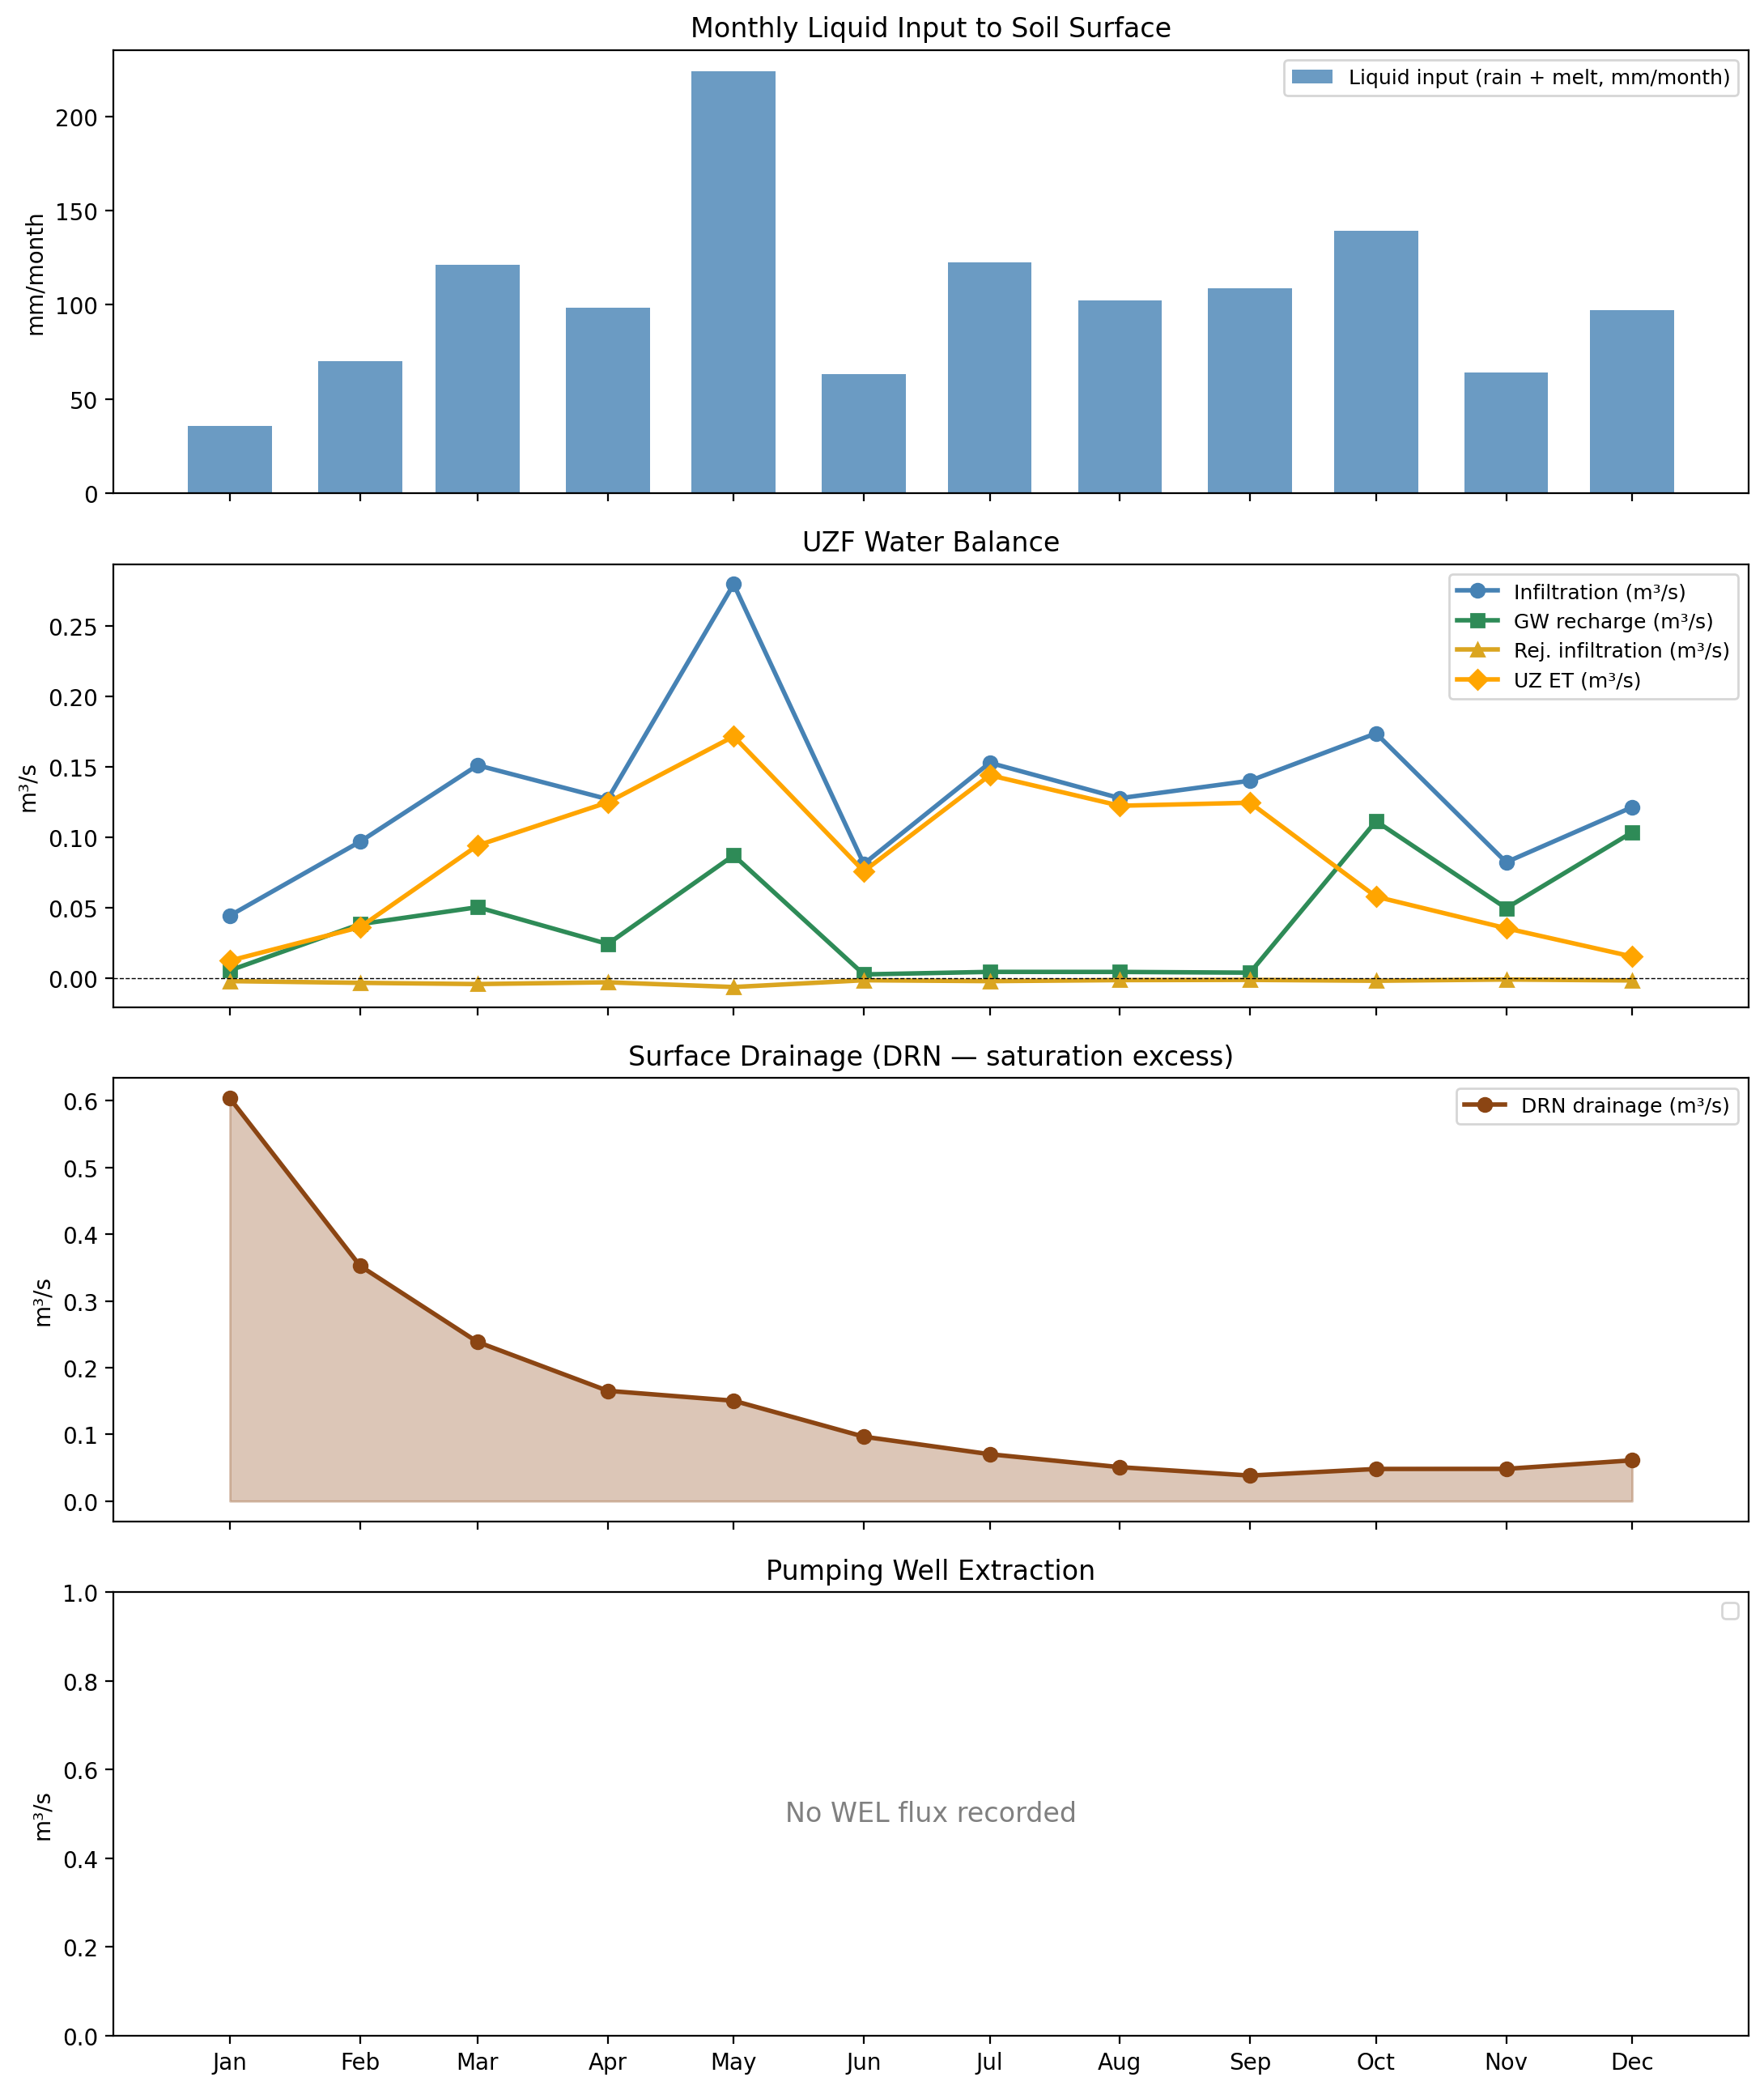

In [56]:
from pathlib import Path as _P
from collections import defaultdict

# ── Open output files ─────────────────────────────────────────────
bobj = bf.CellBudgetFile(str(_P(gwf.model_ws) / f'{gwf.name}.cbc'))
cbc_ksp  = [(int(ks), int(kp)) for ks, kp in bobj.get_kstpkper()]   # cast np.int32 → int
cbc_recs = [t.strip().decode() for t in bobj.get_unique_record_names()]
print('CBC records  :', cbc_recs)
print('CBC kstpkper :', cbc_ksp)
print('kper range   :', min(kp for _,kp in cbc_ksp), '–', max(kp for _,kp in cbc_ksp),
      ' (0-based: 0=Jan … 11=Dec)')

# ── GW recharge: UZF-GWRCH from .cbc ─────────────────────────────
# kper is 0-based in MF6 binary files → use directly as month index.
gwrch = np.zeros(nper)
for kstep, kper in cbc_ksp:
    if 0 <= kper < nper:
        try:
            rec = bobj.get_data(text='UZF-GWRCH', kstpkper=(kstep, kper))[0]
            q = np.asarray(rec['q'] if hasattr(rec, 'dtype') and 'q' in rec.dtype.names else rec)
            gwrch[kper] = float(q.sum())
        except Exception as e:
            print(f'  UZF-GWRCH kstpkper=({kstep},{kper}) error: {e}')

# ── DRN and WEL ───────────────────────────────────────────────────
drn_out, wel_out = np.zeros(nper), np.zeros(nper)
for kstep, kper in cbc_ksp:
    if 0 <= kper < nper:
        for txt, arr in [('DRN', drn_out), ('WEL', wel_out)]:
            try:
                rec = bobj.get_data(text=txt, kstpkper=(kstep, kper))[0]
                q = np.asarray(rec['q'] if hasattr(rec, 'dtype') and 'q' in rec.dtype.names else rec)
                arr[kper] = float(q.sum())
            except Exception:
                pass

# ── UZ ET / infiltration / rej-inf from uzfbud ───────────────────
uzf_bud_path = _P(gwf.model_ws) / f'{gwf.name}.uzfbud'
uzfobj       = bf.CellBudgetFile(str(uzf_bud_path))
uzf_kstpkper = [(int(ks), int(kp)) for ks, kp in uzfobj.get_kstpkper()]
uzf_records  = [t.strip().decode() for t in uzfobj.get_unique_record_names()]
print('UZF records  :', uzf_records)
print('uzfbud kper range:', min(kp for _,kp in uzf_kstpkper), '–',
      max(kp for _,kp in uzf_kstpkper))

def get_uzf_flux(text):
    """Average UZF budget term per stress period over all ATS steps. kper is 0-based."""
    sums = defaultdict(float); counts = defaultdict(int)
    for kstep, kper in uzf_kstpkper:
        if 0 <= kper < nper:
            try:
                rec = uzfobj.get_data(text=text, kstpkper=(kstep, kper))[0]
                q = np.asarray(rec['q'] if hasattr(rec, 'dtype') and 'q' in rec.dtype.names else rec)
                sums[kper]   += float(q.sum())
                counts[kper] += 1
            except Exception:
                pass
    return np.array([sums[k]/counts[k] if counts[k] > 0 else 0.0 for k in range(nper)])

uzet    = get_uzf_flux('UZET')
inf     = get_uzf_flux('INFILTRATION')
rej_inf = get_uzf_flux('REJ-INF')

# ── Sanity check ──────────────────────────────────────────────────
active_area_m2 = (idomain[0] == 1).sum() * dx * dy
ann_rch_mm = (gwrch * np.array(days_in_month) * 86400).sum() / active_area_m2 * 1000
print(f'\nGW recharge   : {gwrch}')
print(f'Infiltration  : {inf}')
print(f'Annual GW recharge depth : {ann_rch_mm:.1f} mm/yr  (target ~200-400 mm for CT forest)')

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(11, 13), sharex=True)

axes[0].bar(month_labels, liquid_monthly, width=20, color='steelblue', alpha=0.8,
            label='Liquid input (rain + melt, mm/month)')
axes[0].set_ylabel('mm/month')
axes[0].set_title('Monthly Liquid Input to Soil Surface')
axes[0].legend(fontsize=9)

axes[1].plot(month_labels, inf,     color='steelblue', lw=2, marker='o', label='Infiltration (m³/s)')
axes[1].plot(month_labels, gwrch,   color='seagreen',  lw=2, marker='s', label='GW recharge (m³/s)')
axes[1].plot(month_labels, rej_inf, color='goldenrod', lw=2, marker='^', label='Rej. infiltration (m³/s)')
axes[1].plot(month_labels, -uzet,   color='orange',    lw=2, marker='D', label='UZ ET (m³/s)')
axes[1].axhline(0, color='k', lw=0.5, ls='--')
axes[1].set_ylabel('m³/s')
axes[1].set_title('UZF Water Balance')
axes[1].legend(fontsize=9)

axes[2].plot(month_labels, np.abs(drn_out), color='saddlebrown', lw=2, marker='o',
             label='DRN drainage (m³/s)')
axes[2].fill_between(month_labels, np.abs(drn_out), alpha=0.3, color='saddlebrown')
axes[2].set_ylabel('m³/s')
axes[2].set_title('Surface Drainage (DRN — saturation excess)')
axes[2].legend(fontsize=9)

if any(v != 0 for v in wel_out):
    axes[3].plot(month_labels, np.abs(wel_out), color='C3', lw=2, marker='o',
                 label='WEL extraction (m³/s)')
    axes[3].fill_between(month_labels, np.abs(wel_out), alpha=0.3, color='C3')
else:
    axes[3].text(0.5, 0.5, 'No WEL flux recorded', transform=axes[3].transAxes,
                 ha='center', va='center', fontsize=12, color='grey')
axes[3].set_ylabel('m³/s')
axes[3].set_title('Pumping Well Extraction')
axes[3].legend(fontsize=9)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.tight_layout()
plt.show()

### 63. Spatial Distribution of UZF Budget

Maps of key unsaturated-zone budget terms aggregated across the 2025 simulation.
All terms are read at every ATS time step and averaged per stress period, then converted
from m³/s per cell to **mm/month** for spatial display.

| Term | Direction | Colormap |
|---|---|---|
| Infiltration | Downward into soil | Blues |
| GW Recharge | Downward into saturated zone | YlGn |
| Rejected Infiltration | Upward — runoff | Oranges |
| UZ ET | Upward — evapotranspiration loss | Reds |

**Figure 1** — Annual mean (average of all 12 months) for each term.  
**Figure 2** — Month-by-month GW recharge maps showing the seasonal recharge pulse.

Annual mean GW recharge  : 0.000 – 101.222 mm/month
Annual mean infiltration : 103.882 – 103.882 mm/month


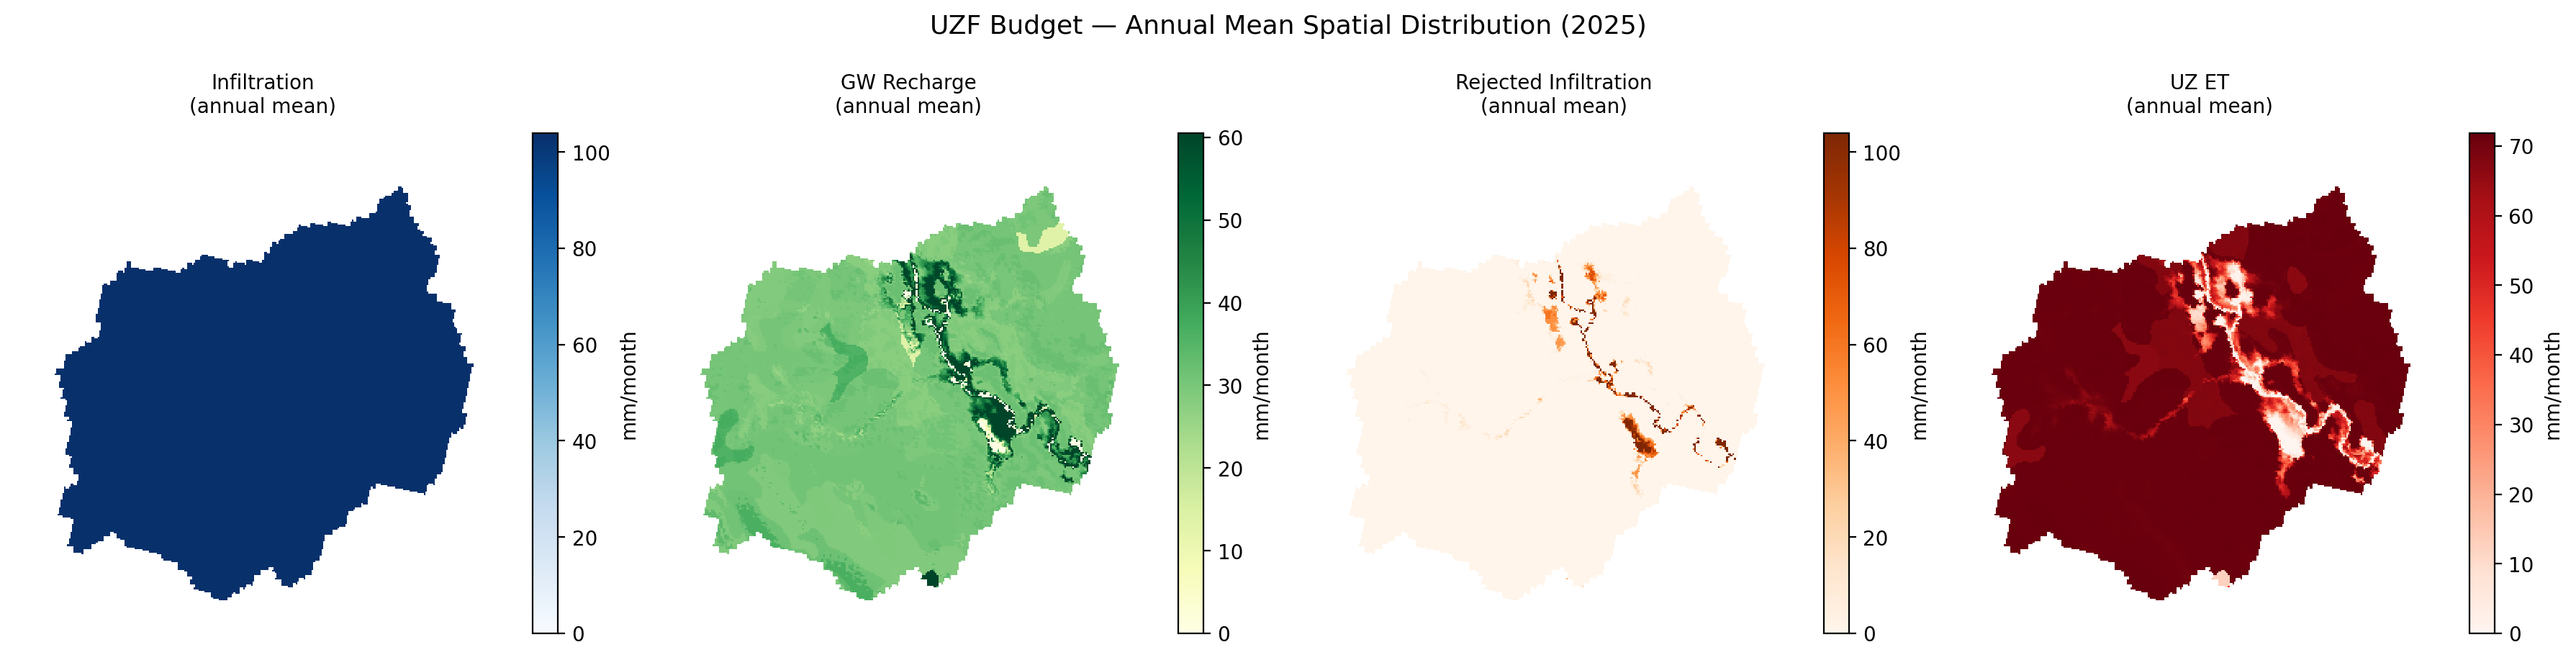

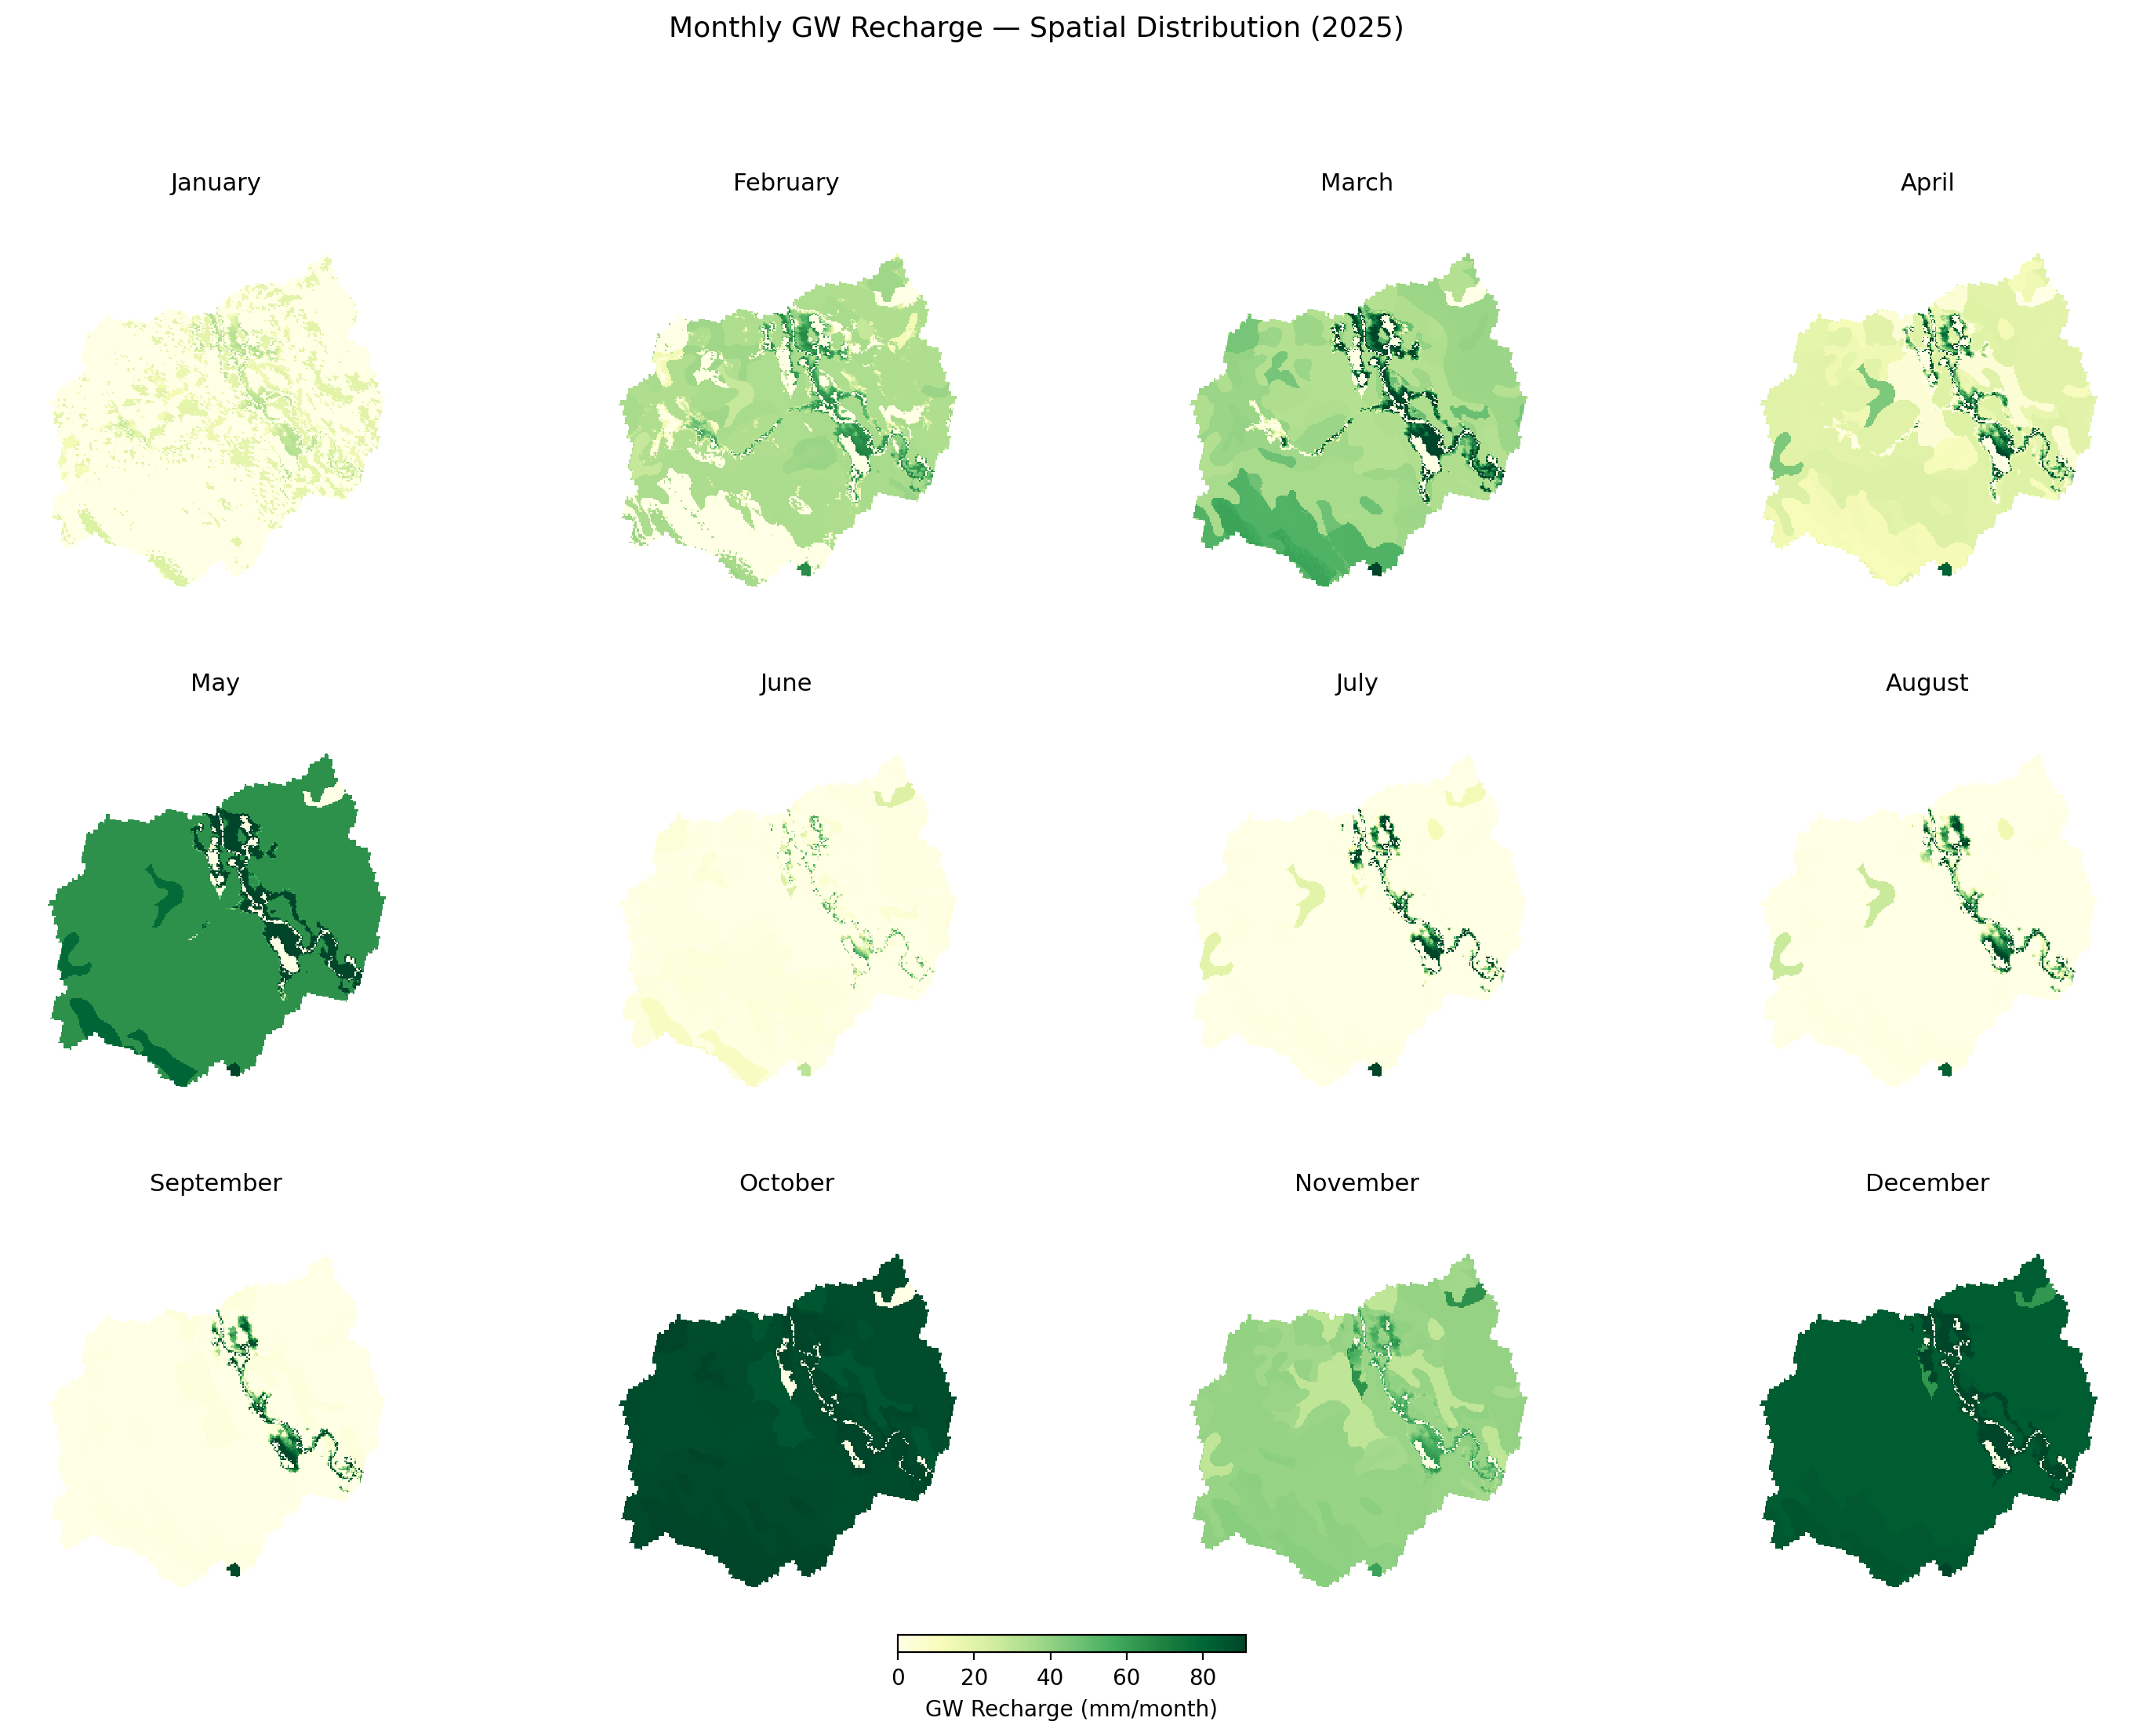

In [49]:
# ── GW recharge spatial: read from .cbc (one record per month, no ATS issues) ──
# UZF package entry in .cbc has node + q for every GWF cell touched by UZF.
# Positive q = water flowing from UZF into GWF = recharge.

def get_rch_spatial_cbc():
    """Return (nper, nrow, ncol) GW recharge [m³/s per cell] from .cbc."""
    out = np.full((nper, nrow, ncol), 0.0)
    for i, (kstep, kper) in enumerate([(int(ks),int(kp)) for ks,kp in bobj.get_kstpkper()]):
        try:
            rec = bobj.get_data(text='UZF-GWRCH', kstpkper=(kstep, kper))[0]
            nodes = np.asarray(rec['node']).flatten() - 1   # 0-based GWF cell index
            q_arr = np.asarray(rec['q']).flatten()
            # Layer 1 cells: node = row*ncol + col  (layer index = node // (nrow*ncol))
            lay_idx = nodes // (nrow * ncol)
            rem     = nodes  % (nrow * ncol)
            row_idx = rem    // ncol
            col_idx = rem     % ncol
            mask    = (lay_idx == 0) & (q_arr > 0)   # layer 1, recharge only
            out[i, row_idx[mask], col_idx[mask]] = q_arr[mask]
        except Exception:
            pass
    return out

# ── UZF spatial helper for other terms (uzfbud, ATS-averaged) ─────
def get_uzf_spatial(text):
    """Return (nper, nrow, ncol) per-cell UZF budget averaged over ATS steps."""
    n      = len(rows_uzf)
    sums   = defaultdict(lambda: np.zeros(n))
    counts = defaultdict(int)
    for kstep, kper in [(int(ks),int(kp)) for ks,kp in uzf_kstpkper]:
        if 0 <= kper < nper:
            try:
                rec = uzfobj.get_data(text=text, kstpkper=(kstep, kper))[0]
                q = np.asarray(rec['q'] if (hasattr(rec, 'dtype') and 'q' in rec.dtype.names)
                               else rec).flatten()
                sums[kper]   += q[:n]
                counts[kper] += 1
            except Exception:
                pass
    out = np.full((nper, nrow, ncol), np.nan)
    for kper in range(nper):
        if counts[kper] > 0:
            a = np.full((nrow, ncol), np.nan)
            a[rows_uzf, cols_uzf] = sums[kper] / counts[kper]
            out[kper] = a
    return out

# ── Read spatial arrays ───────────────────────────────────────────
sp_rch  = get_rch_spatial_cbc()          # from .cbc — reliable
sp_inf  = get_uzf_spatial('INFILTRATION')
sp_rej  = get_uzf_spatial('REJ-INF')
sp_uzet = get_uzf_spatial('UZET')

# ── Convert m³/s per cell → mm/month ─────────────────────────────
def to_mm_month(arr_m3s, month_idx):
    return arr_m3s * days_in_month[month_idx] * 86400.0 / (dx * dy) * 1000.0

rch_mm  = np.stack([to_mm_month(sp_rch[i],           i) for i in range(nper)])
inf_mm  = np.stack([to_mm_month(sp_inf[i],           i) for i in range(nper)])
rej_mm  = np.stack([to_mm_month(np.abs(sp_rej[i]),   i) for i in range(nper)])
uzet_mm = np.stack([to_mm_month(np.abs(sp_uzet[i]),  i) for i in range(nper)])

rch_ann  = np.nanmean(rch_mm,  axis=0)
inf_ann  = np.nanmean(inf_mm,  axis=0)
rej_ann  = np.nanmean(rej_mm,  axis=0)
uzet_ann = np.nanmean(uzet_mm, axis=0)

print(f'Annual mean GW recharge  : {np.nanmin(rch_ann[active]):.3f} – {np.nanmax(rch_ann[active]):.3f} mm/month')
print(f'Annual mean infiltration : {np.nanmin(inf_ann[active]):.3f} – {np.nanmax(inf_ann[active]):.3f} mm/month')

# ── Figure 1: Annual mean — 4 terms ──────────────────────────────
terms_ann = [
    (inf_ann,  'Infiltration',          'Blues'),
    (rch_ann,  'GW Recharge',           'YlGn'),
    (rej_ann,  'Rejected Infiltration', 'Oranges'),
    (uzet_ann, 'UZ ET',                 'Reds'),
]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (data, title, cmap) in zip(axes, terms_ann):
    masked   = np.where(inactive_mask, np.nan, data)
    pos_vals = masked[active & (masked > 0)]
    vmax     = np.nanpercentile(pos_vals, 97) if len(pos_vals) > 0 else 1.0
    im = ax.imshow(masked, cmap=cmap, origin='upper', vmin=0, vmax=vmax, interpolation='none')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='mm/month')
    ax.set_title(f'{title}\n(annual mean)', fontsize=10)
    ax.axis('off')
plt.suptitle('UZF Budget — Annual Mean Spatial Distribution (2025)', fontsize=13)
plt.tight_layout(); plt.show()

# ── Figure 2: Monthly GW recharge maps ───────────────────────────
rch_pos  = rch_mm[rch_mm > 0]
vmax_rch = np.nanpercentile(rch_pos, 97) if len(rch_pos) > 0 else 1.0
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for i, ax in enumerate(axes.flatten()):
    masked = np.where(inactive_mask, np.nan, rch_mm[i])
    im = ax.imshow(masked, cmap='YlGn', origin='upper',
                   vmin=0, vmax=vmax_rch, interpolation='none')
    ax.set_title(calendar.month_name[i + 1], fontsize=11)
    ax.axis('off')
fig.colorbar(im, ax=axes, fraction=0.012, pad=0.01,location='bottom', label='GW Recharge (mm/month)')
plt.suptitle('Monthly GW Recharge — Spatial Distribution (2025)', fontsize=13)
plt.show()

## Summary

This notebook builds a **monthly transient groundwater model** for the UConn Fenton Forest for **2025** (12 stress periods, Jan–Dec):

- **12 monthly stress periods** driven by daily P and T from HBV inputs
- **Snow/rain partition**: degree-day model (DDF mm/day/°C) accumulates SWE in cold months and releases melt in spring — `finf` to UZF = rain + snowmelt, not raw precipitation
- **UZF**: unsaturated zone routing with temperature-corrected HBV PE as ET demand; recharge to the water table is time-lagged through the vadose zone
- **Sy (Layer 1)**: spatially variable from SSURGO θ_s − θ_fc
- **Sy (Layer 2)**: 0.20 (regolith / glacial till literature value)
- **ATS**: adaptive time stepping starting at DT0_HOURS — automatically subdivides or grows the time step based on convergence
- **DRN package**: surface drain at land surface, representing saturation-excess drainage
- **WEL package**: pumping well from `pumping_well.shp` in Layer 2 (regolith)
- **Newton solver** with under-relaxation for robust convergence of convertible layers

